In [1]:
import sys
sys.path.append("..")

from datetime import datetime


import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_score_matching_kbT_loss_per_batch, setup_score_matching_kbT_local_gradient_per_batch, setup_score_matching_kbT_loss_analytical
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time, visualize_connectivity_with_non_local_couplings
from physical_diffusion_fns.network_fns import setup_overdamped_SDE, solve_SDE, create_2d_square_lattice_connectivity,setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn, setup_duffing_network_analytical_derivatives

jax.config.update("jax_enable_x64", True) 

2026-01-16 08:18:11.103691: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Random keys

In [2]:
master_key  = jax.random.PRNGKey(0)          # single seed
sample_target_key, optimization_key, reverse_sde_key = jr.split(master_key, 3)

# Generate samples from a Gaussian mixture - the target distribution

In [3]:
# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.6, .4])

# Define means
means = jnp.array([
    [1., 0.5],   # mean of first Gaussian
    [-1., -0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_target = sample_gaussian_mixture(sample_target_key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal of target distributions

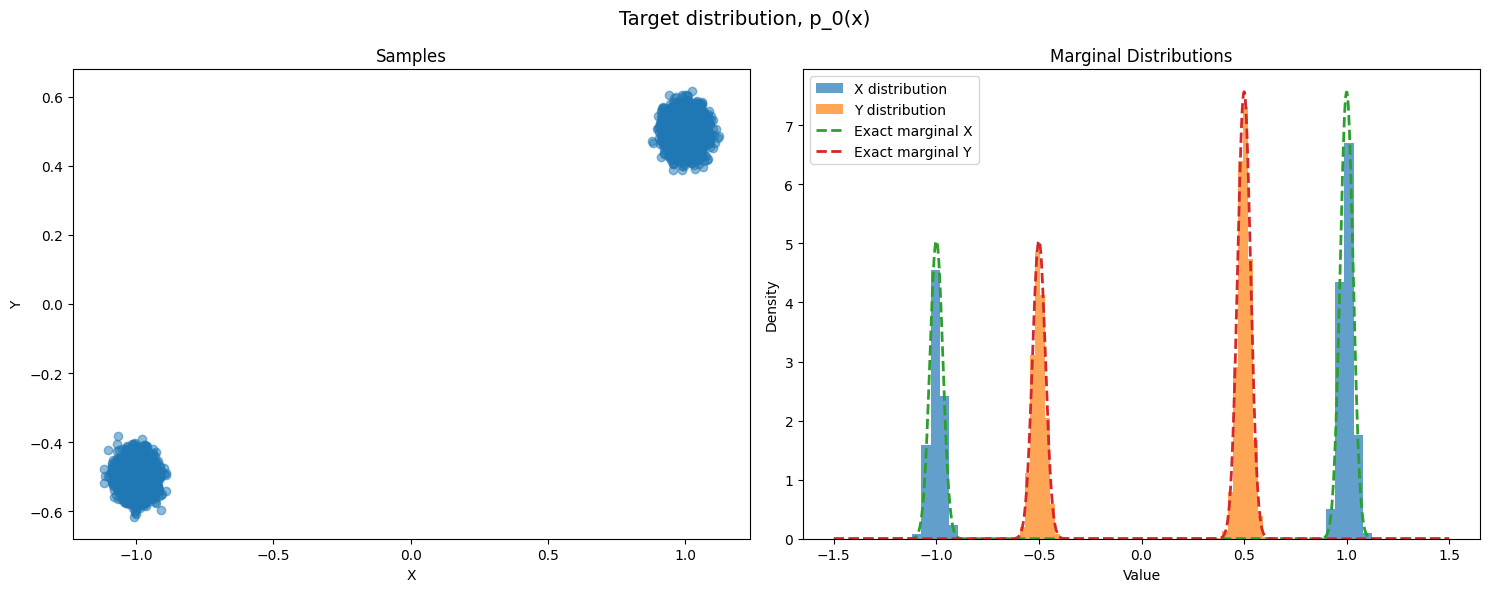

In [4]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_target[:, 0], samples_target[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_target[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_target[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Physical system

## Network size and topology and temperature

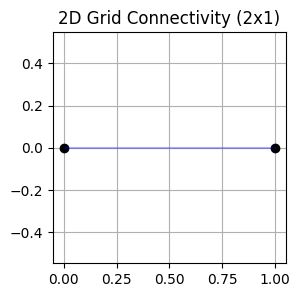

In [5]:
Temp = .005
N_osc = 2
connectivity = jnp.array([[0, 1]])
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

## Energy

In [6]:
energy_fn_type = "6th_order_duffing_coupling"
if energy_fn_type == "6th_order_duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    k_6_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, k_6_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'k_6', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_k6_self = jnp.arange(2*N_osc,3*N_osc)
    constraint_indices = constraint_indices_k6_self

    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn(connectivity, unflatten)
    # Set up analytical derivatives
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)
elif energy_fn_type == "duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_duff_self = jnp.arange(N_osc,2*N_osc)
    constraint_indices_duff_coupling = jnp.arange(2*N_osc+2*num_connections,2*N_osc+3*num_connections)
    constraint_indices = jnp.concatenate([constraint_indices_duff_self, constraint_indices_duff_coupling])
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_energy_fn(connectivity, unflatten)
    # Set up analytical derivatives
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)
elif energy_fn_type == "duffing_optomech_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices = jnp.arange(N_osc,2*N_osc)
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_energy_fn(connectivity, unflatten)
    # Set up analytical derivatives (Note: this function is designed for 6th order duffing coupling, may need adjustment for other energy types)
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)
else:
    raise ValueError(f"Unknown energy function type: {energy_fn_type}. Choose from '6th_order_duffing_coupling' or 'duffing_coupling'.")

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


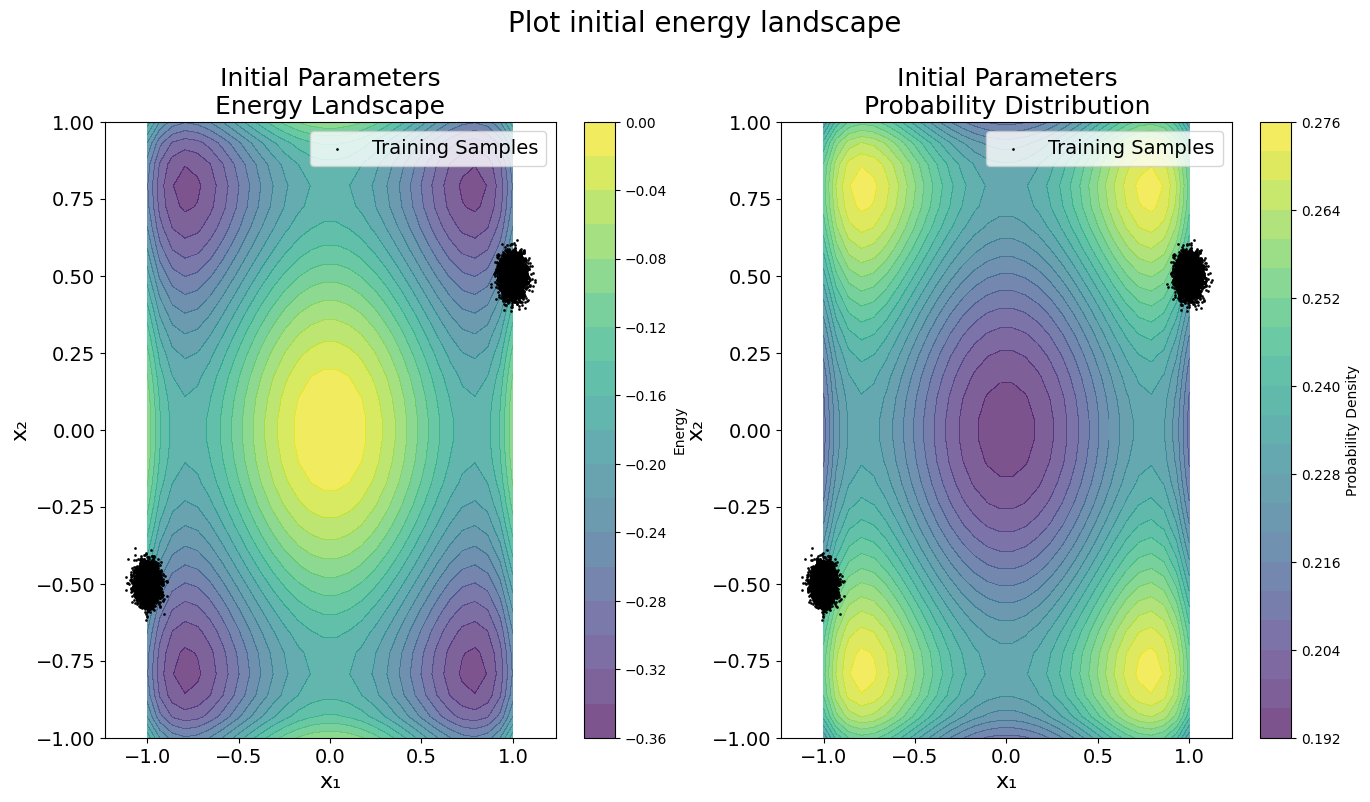

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_target,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
# Choose training method
training_method = "CD1"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "SM_local":
    # Use analytical version for much better performance
    loss_fn_per_batch, gradient_fn_per_batch = setup_score_matching_kbT_loss_analytical(
        gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn, 
        k_b=1.0, T=Temp
    )
    maximize = False
    learning_rate = Temp
elif training_method == "CD1":
    CD1_dt = 0.00001
    CD1_num_noise_samples = 3000
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch, key_CD1: -CD1_gradient(energy_fn, batch, flattened_args, dt=CD1_dt, D=Temp, key=key_CD1, num_noise_samples=CD1_num_noise_samples)
    learning_rate = 0.01*Temp
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")


#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 15
t_forward = 5.
sigma_forward = 1.
exponential_time_pts = False
if exponential_time_pts:
    forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-7), jnp.log(t_forward), n_time_steps))
    forward_time_pts = forward_time_pts.at[0].set(0.)
else:
    forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
# print('forward_time_pts', forward_time_pts)

# Optimization parameters

n_epochs = 100000
batch_size = 16*128
window_size=500
tolerance=1e-4
patience=100

In [10]:
problem_type_folder = f"gaussian_mixture/Energy_fn_type_{energy_fn_type}_Temp_{Temp}"
optimization_folder = (
        f"training_method_{training_method}_"
    + (f"CD1_dt_{CD1_dt}_CD1_num_noise_samples_{CD1_num_noise_samples}_" if training_method == "CD1" else "")
    + f"exp_time_pts_{exponential_time_pts}_"
    + f"t_forward_{t_forward}_"
    + f"n_timesteps_{n_time_steps}_"
        f"sigma_forward_{sigma_forward}_"
        f"lr_{learning_rate}_"
        f"epochs_{n_epochs}_"
        f"batch_{batch_size}_"
        f"window_{window_size}_"
        f"tol_{tolerance}_"
        f"patience_{patience}")

# Setup output directories
# here = os.path.dirname(os.path.abspath(__file__))
current_date = datetime.now().strftime("%Y_%m_%d")

base_dir = "../out/problems"
output_dir = os.path.join(base_dir, current_date,problem_type_folder, f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}", optimization_folder)
plot_folder = os.path.join(output_dir, 'aaa_final_plots')

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plot_folder, exist_ok=True)
print(f"Output directory: {output_dir}")
print(f"Plot directory: {plot_folder}")

save_fig = False

Output directory: ../out/problems/2026_01_16/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling_Temp_0.005/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/training_method_CD1_CD1_dt_1e-05_CD1_num_noise_samples_3000_exp_time_pts_False_t_forward_5.0_n_timesteps_15_sigma_forward_1.0_lr_5e-05_epochs_100000_batch_2048_window_500_tol_0.0001_patience_100
Plot directory: ../out/problems/2026_01_16/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling_Temp_0.005/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/training_method_CD1_CD1_dt_1e-05_CD1_num_noise_samples_3000_exp_time_pts_False_t_forward_5.0_n_timesteps_15_sigma_forward_1.0_lr_5e-05_epochs_100000_batch_2048_window_500_tol_0.0001_patience_100/aaa_final_plots


t_idx: 0, t_curr: 0.0


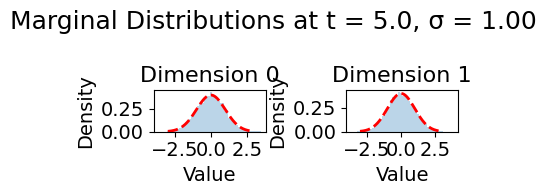

Epoch 0 - Loss: -6.5017 - Best Loss: -6.5017 (Epoch 0)
Epoch 100 - Loss: -6.4775 - Best Loss: -6.5353 (Epoch 8)
Epoch 200 - Loss: -6.4487 - Best Loss: -6.5353 (Epoch 8)
Epoch 300 - Loss: -6.4017 - Best Loss: -6.5353 (Epoch 8)
Epoch 400 - Loss: -6.3806 - Best Loss: -6.5353 (Epoch 8)
Epoch 500 - Loss: -6.3526 - Best Loss: -6.5353 (Epoch 8)
Epoch 600 - Loss: -6.3411 - Best Loss: -6.5353 (Epoch 8)
Epoch 700 - Loss: -6.3236 - Best Loss: -6.5353 (Epoch 8)
Epoch 800 - Loss: -6.2986 - Best Loss: -6.5353 (Epoch 8)
Epoch 900 - Loss: -6.2971 - Best Loss: -6.5353 (Epoch 8)
Epoch 1000 - Loss: -6.2508 - Best Loss: -6.5353 (Epoch 8)
Epoch 1100 - Loss: -6.2407 - Best Loss: -6.5353 (Epoch 8)
Epoch 1200 - Loss: -6.2537 - Best Loss: -6.5353 (Epoch 8)
Epoch 1300 - Loss: -6.2442 - Best Loss: -6.5353 (Epoch 8)
Epoch 1400 - Loss: -6.2187 - Best Loss: -6.5353 (Epoch 8)
Epoch 1500 - Loss: -6.2205 - Best Loss: -6.5353 (Epoch 8)
Epoch 1600 - Loss: -6.2018 - Best Loss: -6.5353 (Epoch 8)
Epoch 1700 - Loss: -6.2210

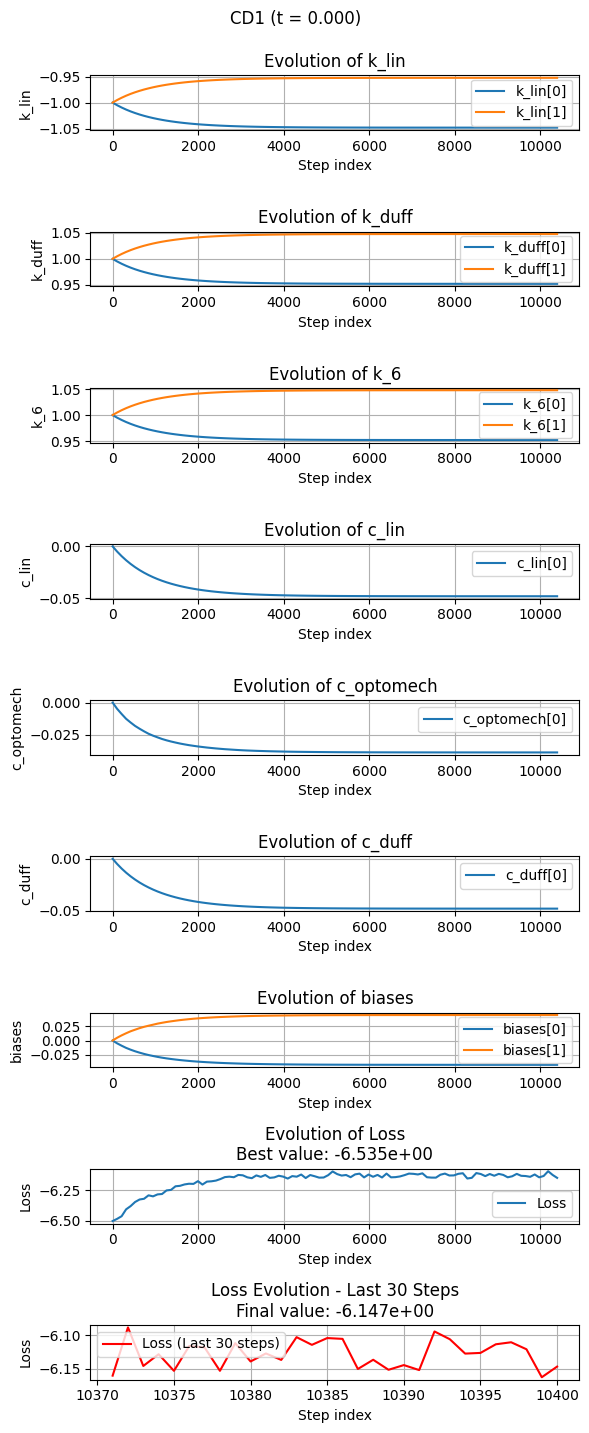

t_idx: 1, t_curr: 0.3571428571428571
Epoch 0 - Loss: -1.1517 - Best Loss: -1.1517 (Epoch 0)
Epoch 100 - Loss: -1.1103 - Best Loss: -1.1517 (Epoch 0)
Epoch 200 - Loss: -1.1421 - Best Loss: -1.1717 (Epoch 113)
Epoch 300 - Loss: -1.1551 - Best Loss: -1.1717 (Epoch 113)
Epoch 400 - Loss: -1.1607 - Best Loss: -1.1717 (Epoch 113)
Epoch 500 - Loss: -1.1480 - Best Loss: -1.1725 (Epoch 489)
Epoch 600 - Loss: -1.1573 - Best Loss: -1.1862 (Epoch 587)
Epoch 700 - Loss: -1.1634 - Best Loss: -1.1875 (Epoch 647)
Epoch 800 - Loss: -1.1397 - Best Loss: -1.1887 (Epoch 752)
Epoch 900 - Loss: -1.1509 - Best Loss: -1.1887 (Epoch 752)
Epoch 1000 - Loss: -1.1347 - Best Loss: -1.1892 (Epoch 957)
Epoch 1100 - Loss: -1.1771 - Best Loss: -1.1991 (Epoch 1007)
Epoch 1200 - Loss: -1.1777 - Best Loss: -1.1991 (Epoch 1007)
Epoch 1300 - Loss: -1.1522 - Best Loss: -1.1991 (Epoch 1007)
Epoch 1400 - Loss: -1.1498 - Best Loss: -1.2014 (Epoch 1337)
Epoch 1500 - Loss: -1.1683 - Best Loss: -1.2135 (Epoch 1460)
Epoch 1600 - L

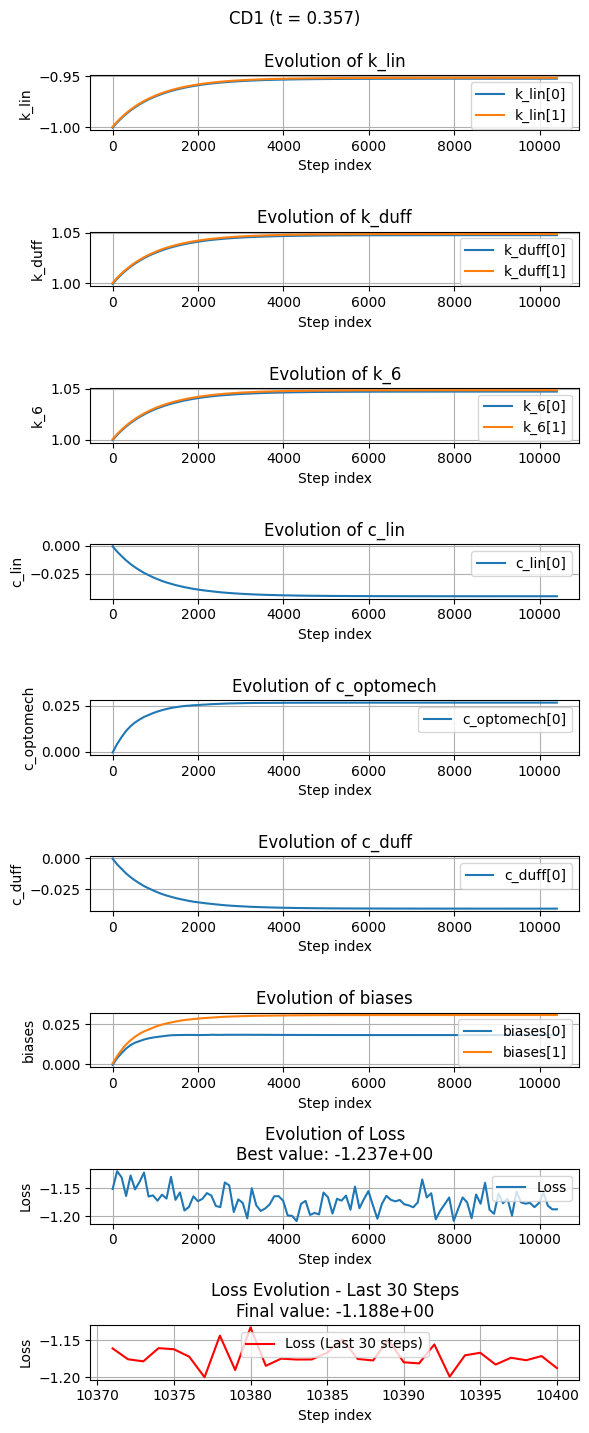

t_idx: 2, t_curr: 0.7142857142857142
Epoch 0 - Loss: 0.8427 - Best Loss: 0.8427 (Epoch 0)
Epoch 100 - Loss: 0.8039 - Best Loss: 0.7922 (Epoch 86)
Epoch 200 - Loss: 0.7625 - Best Loss: 0.7593 (Epoch 175)
Epoch 300 - Loss: 0.7502 - Best Loss: 0.7261 (Epoch 253)
Epoch 400 - Loss: 0.7107 - Best Loss: 0.6990 (Epoch 397)
Epoch 500 - Loss: 0.6950 - Best Loss: 0.6744 (Epoch 495)
Epoch 600 - Loss: 0.6655 - Best Loss: 0.6515 (Epoch 590)
Epoch 700 - Loss: 0.6387 - Best Loss: 0.6341 (Epoch 683)
Epoch 800 - Loss: 0.6305 - Best Loss: 0.6175 (Epoch 772)
Epoch 900 - Loss: 0.6311 - Best Loss: 0.6022 (Epoch 883)
Epoch 1000 - Loss: 0.5876 - Best Loss: 0.5858 (Epoch 991)
Epoch 1100 - Loss: 0.6016 - Best Loss: 0.5672 (Epoch 1091)
Epoch 1200 - Loss: 0.5694 - Best Loss: 0.5517 (Epoch 1188)
Epoch 1300 - Loss: 0.5690 - Best Loss: 0.5469 (Epoch 1297)
Epoch 1400 - Loss: 0.5566 - Best Loss: 0.5382 (Epoch 1381)
Epoch 1500 - Loss: 0.5444 - Best Loss: 0.5262 (Epoch 1492)
Epoch 1600 - Loss: 0.5509 - Best Loss: 0.5210

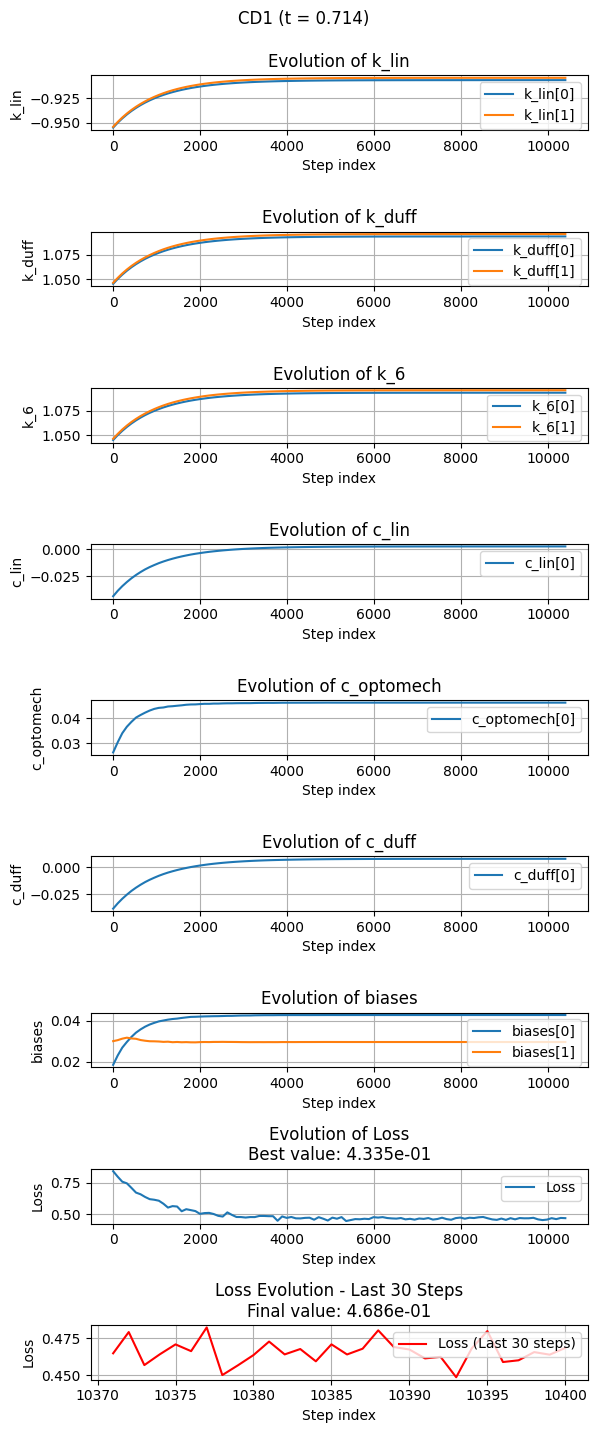

t_idx: 3, t_curr: 1.0714285714285712
Epoch 0 - Loss: 1.2311 - Best Loss: 1.2311 (Epoch 0)
Epoch 100 - Loss: 1.1933 - Best Loss: 1.1864 (Epoch 95)
Epoch 200 - Loss: 1.1584 - Best Loss: 1.1568 (Epoch 193)
Epoch 300 - Loss: 1.1449 - Best Loss: 1.1265 (Epoch 299)
Epoch 400 - Loss: 1.1109 - Best Loss: 1.1069 (Epoch 392)
Epoch 500 - Loss: 1.0876 - Best Loss: 1.0850 (Epoch 495)
Epoch 600 - Loss: 1.0720 - Best Loss: 1.0669 (Epoch 593)
Epoch 700 - Loss: 1.0590 - Best Loss: 1.0460 (Epoch 699)
Epoch 800 - Loss: 1.0274 - Best Loss: 1.0269 (Epoch 798)
Epoch 900 - Loss: 1.0202 - Best Loss: 1.0151 (Epoch 888)
Epoch 1000 - Loss: 1.0178 - Best Loss: 1.0079 (Epoch 971)
Epoch 1100 - Loss: 1.0036 - Best Loss: 0.9919 (Epoch 1096)
Epoch 1200 - Loss: 1.0002 - Best Loss: 0.9799 (Epoch 1165)
Epoch 1300 - Loss: 0.9782 - Best Loss: 0.9739 (Epoch 1277)
Epoch 1400 - Loss: 0.9651 - Best Loss: 0.9627 (Epoch 1353)
Epoch 1500 - Loss: 0.9669 - Best Loss: 0.9599 (Epoch 1439)
Epoch 1600 - Loss: 0.9530 - Best Loss: 0.9466

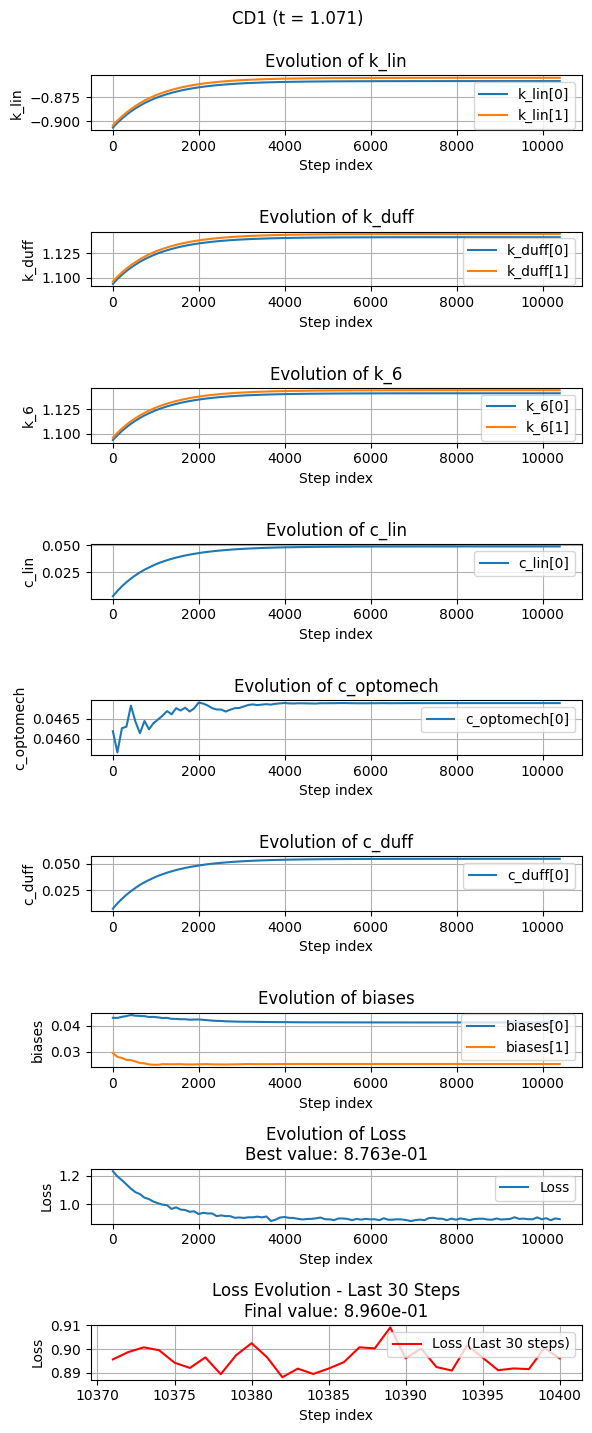

t_idx: 4, t_curr: 1.4285714285714284
Epoch 0 - Loss: 1.2174 - Best Loss: 1.2174 (Epoch 0)
Epoch 100 - Loss: 1.1846 - Best Loss: 1.1834 (Epoch 94)
Epoch 200 - Loss: 1.1564 - Best Loss: 1.1543 (Epoch 195)
Epoch 300 - Loss: 1.1335 - Best Loss: 1.1321 (Epoch 292)
Epoch 400 - Loss: 1.1143 - Best Loss: 1.1106 (Epoch 396)
Epoch 500 - Loss: 1.0926 - Best Loss: 1.0890 (Epoch 487)
Epoch 600 - Loss: 1.0709 - Best Loss: 1.0709 (Epoch 600)
Epoch 700 - Loss: 1.0597 - Best Loss: 1.0559 (Epoch 699)
Epoch 800 - Loss: 1.0440 - Best Loss: 1.0403 (Epoch 793)
Epoch 900 - Loss: 1.0360 - Best Loss: 1.0268 (Epoch 873)
Epoch 1000 - Loss: 1.0185 - Best Loss: 1.0151 (Epoch 940)
Epoch 1100 - Loss: 1.0149 - Best Loss: 1.0052 (Epoch 1093)
Epoch 1200 - Loss: 0.9965 - Best Loss: 0.9926 (Epoch 1162)
Epoch 1300 - Loss: 0.9912 - Best Loss: 0.9864 (Epoch 1298)
Epoch 1400 - Loss: 0.9780 - Best Loss: 0.9780 (Epoch 1400)
Epoch 1500 - Loss: 0.9777 - Best Loss: 0.9709 (Epoch 1445)
Epoch 1600 - Loss: 0.9681 - Best Loss: 0.9658

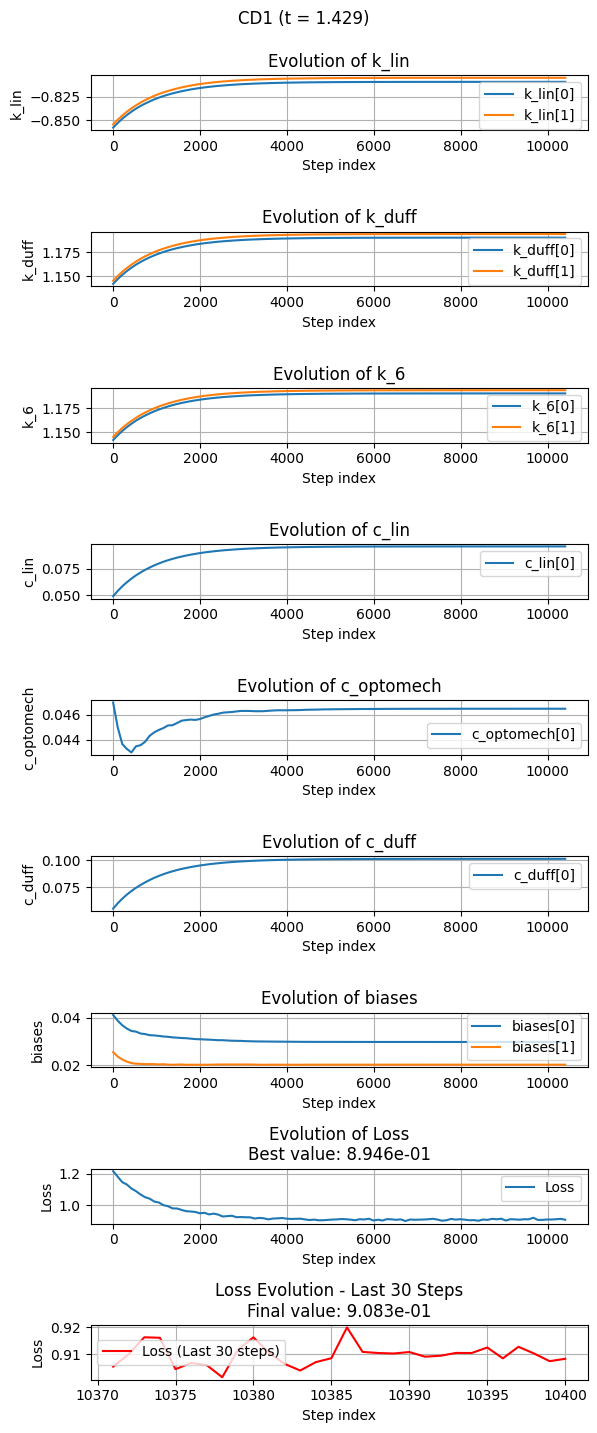

t_idx: 5, t_curr: 1.7857142857142856
Epoch 0 - Loss: 1.0556 - Best Loss: 1.0556 (Epoch 0)
Epoch 100 - Loss: 1.0309 - Best Loss: 1.0266 (Epoch 95)
Epoch 200 - Loss: 1.0019 - Best Loss: 0.9998 (Epoch 199)
Epoch 300 - Loss: 0.9716 - Best Loss: 0.9716 (Epoch 300)
Epoch 400 - Loss: 0.9563 - Best Loss: 0.9538 (Epoch 385)
Epoch 500 - Loss: 0.9377 - Best Loss: 0.9347 (Epoch 478)
Epoch 600 - Loss: 0.9195 - Best Loss: 0.9187 (Epoch 586)
Epoch 700 - Loss: 0.9044 - Best Loss: 0.9029 (Epoch 699)
Epoch 800 - Loss: 0.8889 - Best Loss: 0.8848 (Epoch 795)
Epoch 900 - Loss: 0.8808 - Best Loss: 0.8746 (Epoch 897)
Epoch 1000 - Loss: 0.8655 - Best Loss: 0.8635 (Epoch 996)
Epoch 1100 - Loss: 0.8580 - Best Loss: 0.8504 (Epoch 1096)
Epoch 1200 - Loss: 0.8469 - Best Loss: 0.8440 (Epoch 1179)
Epoch 1300 - Loss: 0.8430 - Best Loss: 0.8318 (Epoch 1295)
Epoch 1400 - Loss: 0.8310 - Best Loss: 0.8282 (Epoch 1384)
Epoch 1500 - Loss: 0.8257 - Best Loss: 0.8212 (Epoch 1479)
Epoch 1600 - Loss: 0.8166 - Best Loss: 0.8159

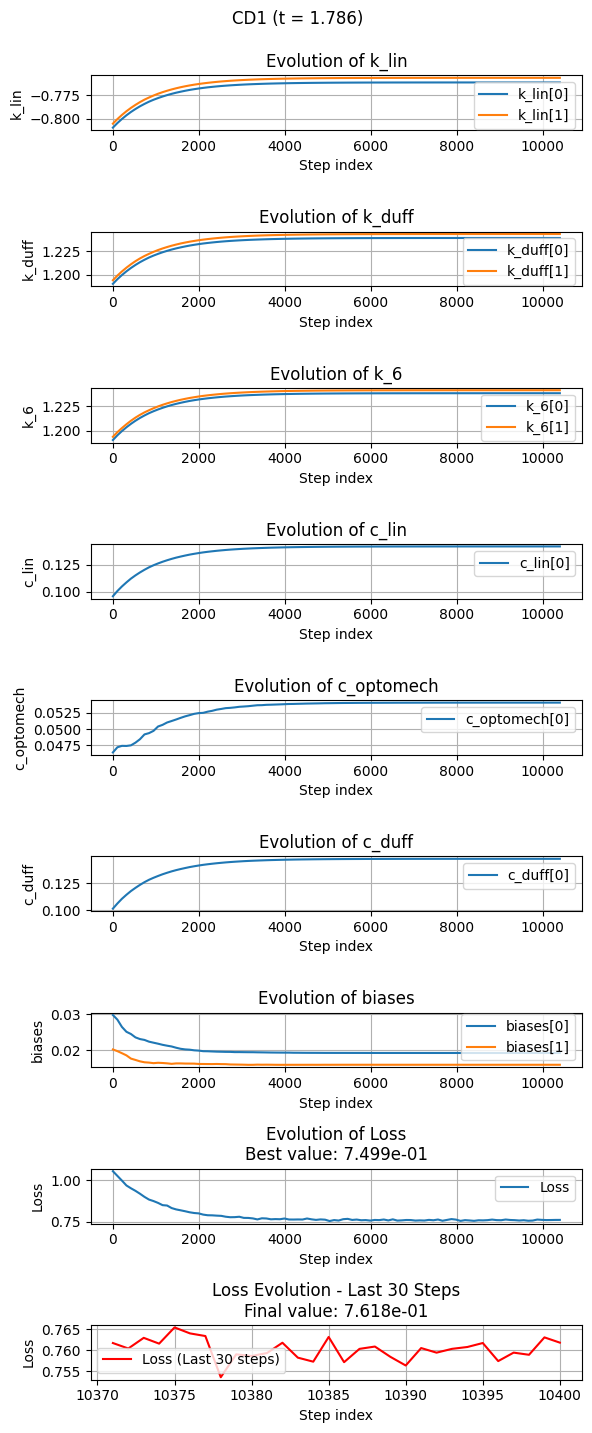

t_idx: 6, t_curr: 2.1428571428571423
Epoch 0 - Loss: 0.8334 - Best Loss: 0.8334 (Epoch 0)
Epoch 100 - Loss: 0.8043 - Best Loss: 0.8032 (Epoch 99)
Epoch 200 - Loss: 0.7786 - Best Loss: 0.7776 (Epoch 199)
Epoch 300 - Loss: 0.7559 - Best Loss: 0.7535 (Epoch 299)
Epoch 400 - Loss: 0.7389 - Best Loss: 0.7325 (Epoch 397)
Epoch 500 - Loss: 0.7156 - Best Loss: 0.7143 (Epoch 491)
Epoch 600 - Loss: 0.7014 - Best Loss: 0.6981 (Epoch 581)
Epoch 700 - Loss: 0.6835 - Best Loss: 0.6826 (Epoch 694)
Epoch 800 - Loss: 0.6683 - Best Loss: 0.6683 (Epoch 800)
Epoch 900 - Loss: 0.6631 - Best Loss: 0.6563 (Epoch 894)
Epoch 1000 - Loss: 0.6486 - Best Loss: 0.6464 (Epoch 996)
Epoch 1100 - Loss: 0.6361 - Best Loss: 0.6355 (Epoch 1093)
Epoch 1200 - Loss: 0.6311 - Best Loss: 0.6258 (Epoch 1182)
Epoch 1300 - Loss: 0.6196 - Best Loss: 0.6137 (Epoch 1288)
Epoch 1400 - Loss: 0.6161 - Best Loss: 0.6090 (Epoch 1397)
Epoch 1500 - Loss: 0.6089 - Best Loss: 0.6043 (Epoch 1490)
Epoch 1600 - Loss: 0.6027 - Best Loss: 0.5981

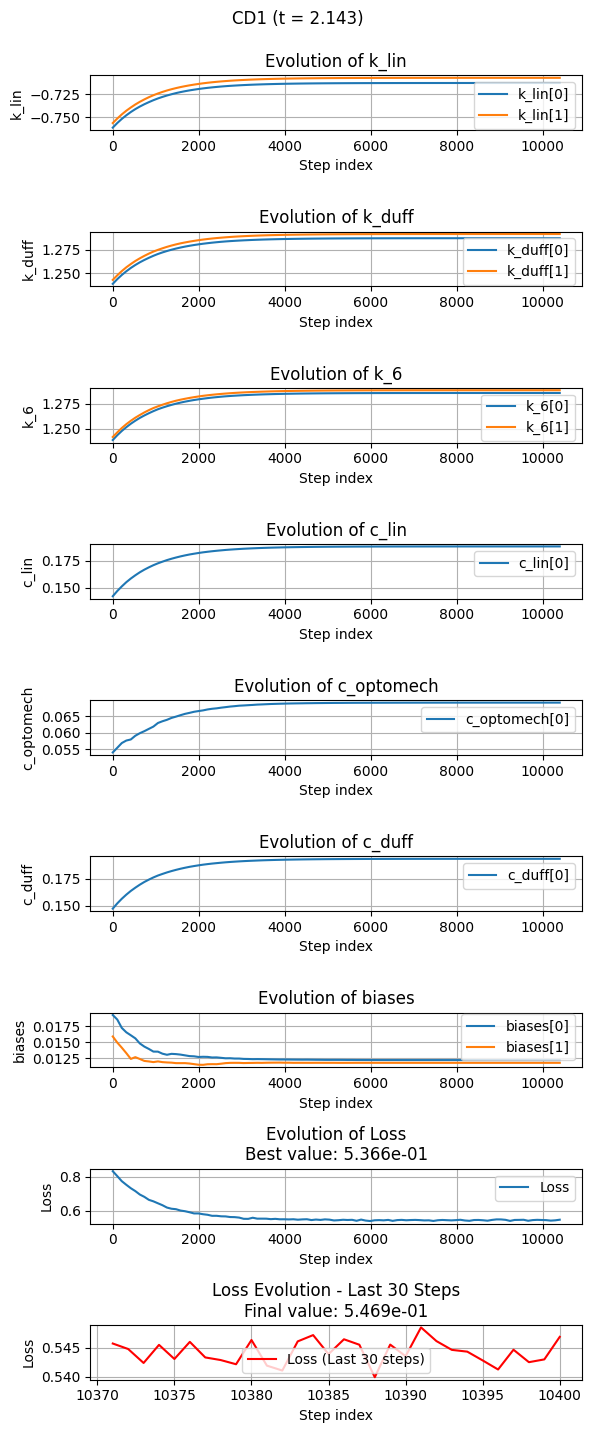

t_idx: 7, t_curr: 2.4999999999999996
Epoch 0 - Loss: 0.5814 - Best Loss: 0.5814 (Epoch 0)
Epoch 100 - Loss: 0.5569 - Best Loss: 0.5537 (Epoch 92)
Epoch 200 - Loss: 0.5294 - Best Loss: 0.5260 (Epoch 196)
Epoch 300 - Loss: 0.5090 - Best Loss: 0.5039 (Epoch 295)
Epoch 400 - Loss: 0.4850 - Best Loss: 0.4842 (Epoch 393)
Epoch 500 - Loss: 0.4646 - Best Loss: 0.4642 (Epoch 499)
Epoch 600 - Loss: 0.4510 - Best Loss: 0.4473 (Epoch 599)
Epoch 700 - Loss: 0.4374 - Best Loss: 0.4337 (Epoch 697)
Epoch 800 - Loss: 0.4217 - Best Loss: 0.4185 (Epoch 799)
Epoch 900 - Loss: 0.4072 - Best Loss: 0.4072 (Epoch 900)
Epoch 1000 - Loss: 0.3999 - Best Loss: 0.3975 (Epoch 997)
Epoch 1100 - Loss: 0.3916 - Best Loss: 0.3888 (Epoch 1094)
Epoch 1200 - Loss: 0.3801 - Best Loss: 0.3786 (Epoch 1172)
Epoch 1300 - Loss: 0.3760 - Best Loss: 0.3699 (Epoch 1285)
Epoch 1400 - Loss: 0.3666 - Best Loss: 0.3627 (Epoch 1397)
Epoch 1500 - Loss: 0.3619 - Best Loss: 0.3575 (Epoch 1496)
Epoch 1600 - Loss: 0.3590 - Best Loss: 0.3508

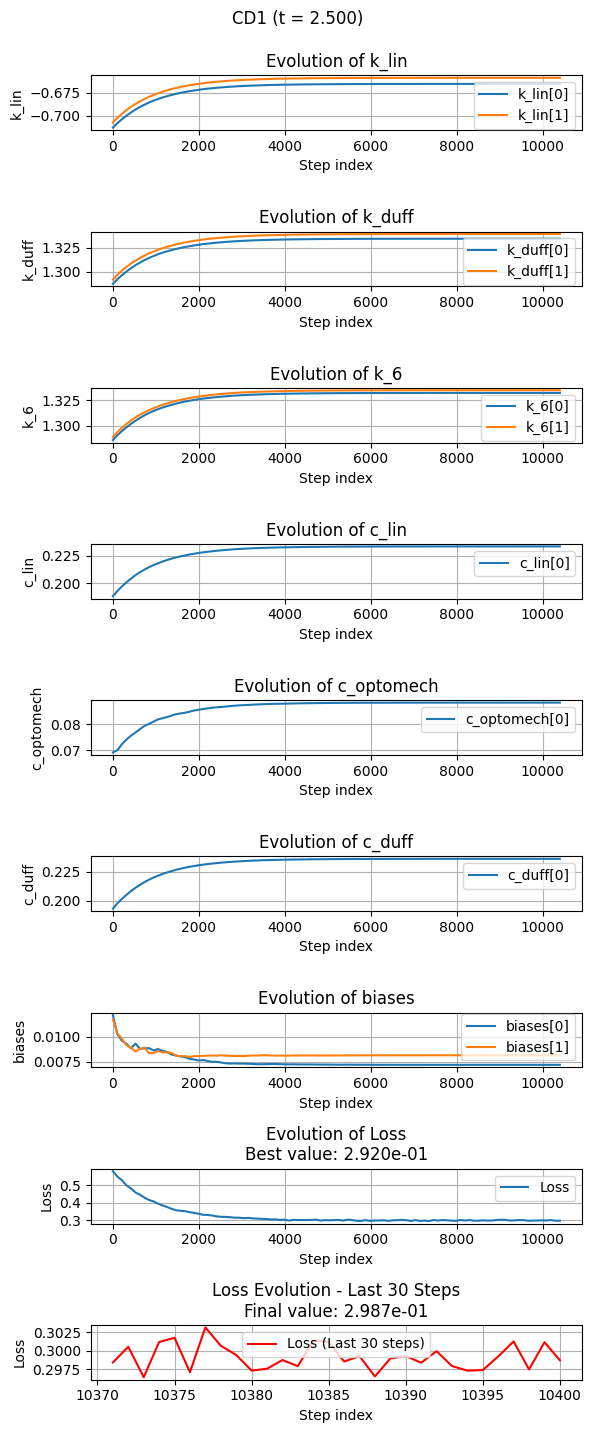

t_idx: 8, t_curr: 2.8571428571428568
Epoch 0 - Loss: 0.3193 - Best Loss: 0.3193 (Epoch 0)
Epoch 100 - Loss: 0.2883 - Best Loss: 0.2883 (Epoch 100)
Epoch 200 - Loss: 0.2675 - Best Loss: 0.2662 (Epoch 185)
Epoch 300 - Loss: 0.2474 - Best Loss: 0.2463 (Epoch 292)
Epoch 400 - Loss: 0.2276 - Best Loss: 0.2258 (Epoch 397)
Epoch 500 - Loss: 0.2095 - Best Loss: 0.2062 (Epoch 499)
Epoch 600 - Loss: 0.1945 - Best Loss: 0.1919 (Epoch 597)
Epoch 700 - Loss: 0.1805 - Best Loss: 0.1795 (Epoch 698)
Epoch 800 - Loss: 0.1674 - Best Loss: 0.1652 (Epoch 797)
Epoch 900 - Loss: 0.1556 - Best Loss: 0.1556 (Epoch 886)
Epoch 1000 - Loss: 0.1457 - Best Loss: 0.1438 (Epoch 998)
Epoch 1100 - Loss: 0.1324 - Best Loss: 0.1324 (Epoch 1100)
Epoch 1200 - Loss: 0.1283 - Best Loss: 0.1251 (Epoch 1198)
Epoch 1300 - Loss: 0.1183 - Best Loss: 0.1183 (Epoch 1300)
Epoch 1400 - Loss: 0.1141 - Best Loss: 0.1131 (Epoch 1383)
Epoch 1500 - Loss: 0.1098 - Best Loss: 0.1072 (Epoch 1496)
Epoch 1600 - Loss: 0.1052 - Best Loss: 0.101

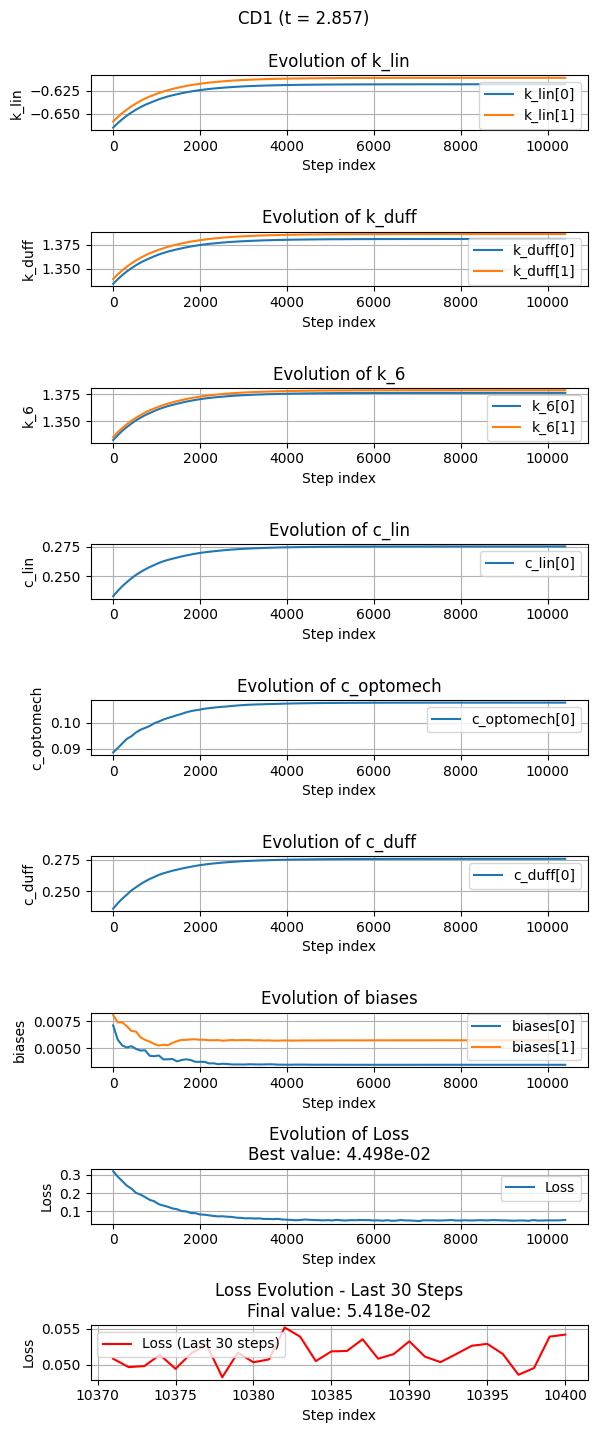

t_idx: 9, t_curr: 3.214285714285714
Epoch 0 - Loss: 0.0588 - Best Loss: 0.0588 (Epoch 0)
Epoch 100 - Loss: 0.0349 - Best Loss: 0.0347 (Epoch 93)
Epoch 200 - Loss: 0.0094 - Best Loss: 0.0093 (Epoch 194)
Epoch 300 - Loss: -0.0092 - Best Loss: -0.0109 (Epoch 297)
Epoch 400 - Loss: -0.0263 - Best Loss: -0.0273 (Epoch 390)
Epoch 500 - Loss: -0.0408 - Best Loss: -0.0430 (Epoch 495)
Epoch 600 - Loss: -0.0545 - Best Loss: -0.0574 (Epoch 590)
Epoch 700 - Loss: -0.0673 - Best Loss: -0.0689 (Epoch 691)
Epoch 800 - Loss: -0.0804 - Best Loss: -0.0810 (Epoch 794)
Epoch 900 - Loss: -0.0879 - Best Loss: -0.0921 (Epoch 896)
Epoch 1000 - Loss: -0.0990 - Best Loss: -0.1021 (Epoch 999)
Epoch 1100 - Loss: -0.1088 - Best Loss: -0.1107 (Epoch 1083)
Epoch 1200 - Loss: -0.1156 - Best Loss: -0.1174 (Epoch 1174)
Epoch 1300 - Loss: -0.1209 - Best Loss: -0.1247 (Epoch 1279)
Epoch 1400 - Loss: -0.1288 - Best Loss: -0.1329 (Epoch 1387)
Epoch 1500 - Loss: -0.1338 - Best Loss: -0.1368 (Epoch 1474)
Epoch 1600 - Loss: -

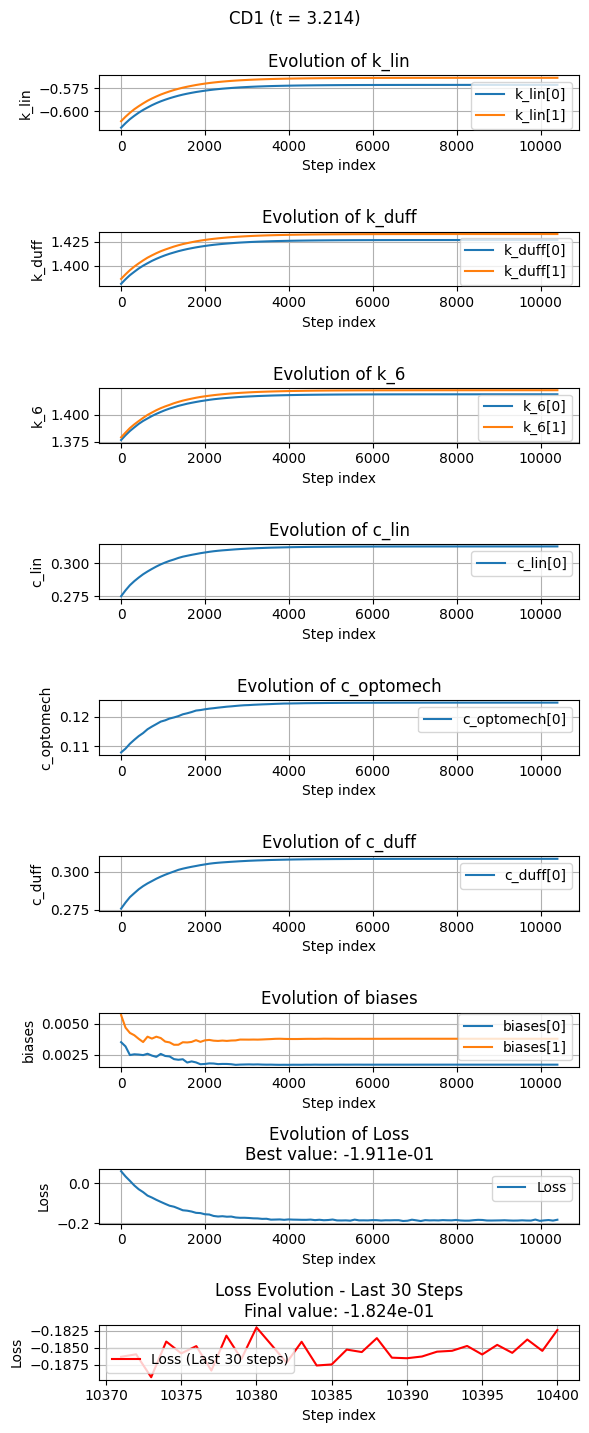

t_idx: 10, t_curr: 3.571428571428571
Epoch 0 - Loss: -0.1811 - Best Loss: -0.1811 (Epoch 0)
Epoch 100 - Loss: -0.2044 - Best Loss: -0.2050 (Epoch 95)
Epoch 200 - Loss: -0.2226 - Best Loss: -0.2241 (Epoch 191)
Epoch 300 - Loss: -0.2380 - Best Loss: -0.2401 (Epoch 294)
Epoch 400 - Loss: -0.2537 - Best Loss: -0.2560 (Epoch 388)
Epoch 500 - Loss: -0.2668 - Best Loss: -0.2691 (Epoch 475)
Epoch 600 - Loss: -0.2782 - Best Loss: -0.2819 (Epoch 580)
Epoch 700 - Loss: -0.2882 - Best Loss: -0.2919 (Epoch 689)
Epoch 800 - Loss: -0.3017 - Best Loss: -0.3017 (Epoch 800)
Epoch 900 - Loss: -0.3088 - Best Loss: -0.3096 (Epoch 892)
Epoch 1000 - Loss: -0.3186 - Best Loss: -0.3203 (Epoch 983)
Epoch 1100 - Loss: -0.3235 - Best Loss: -0.3262 (Epoch 1087)
Epoch 1200 - Loss: -0.3300 - Best Loss: -0.3326 (Epoch 1193)
Epoch 1300 - Loss: -0.3354 - Best Loss: -0.3374 (Epoch 1290)
Epoch 1400 - Loss: -0.3408 - Best Loss: -0.3443 (Epoch 1396)
Epoch 1500 - Loss: -0.3448 - Best Loss: -0.3476 (Epoch 1481)
Epoch 1600 - 

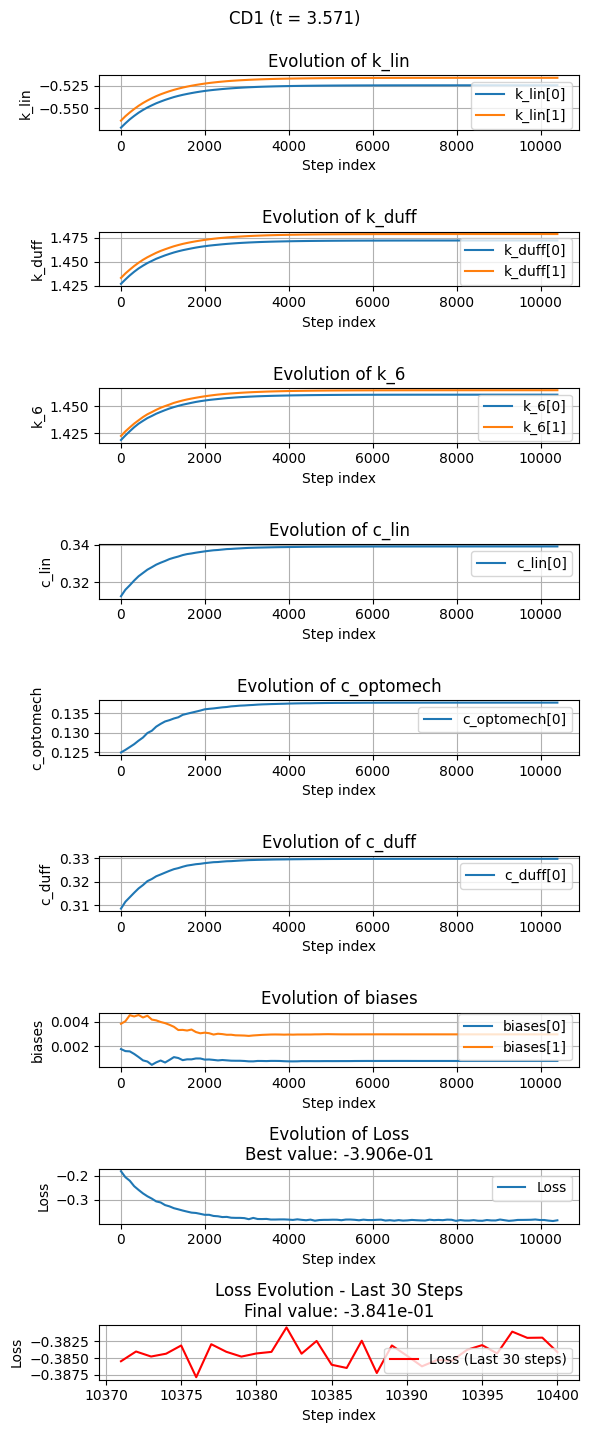

t_idx: 11, t_curr: 3.928571428571428
Epoch 0 - Loss: -0.3811 - Best Loss: -0.3811 (Epoch 0)
Epoch 100 - Loss: -0.3983 - Best Loss: -0.4021 (Epoch 95)
Epoch 200 - Loss: -0.4118 - Best Loss: -0.4140 (Epoch 189)
Epoch 300 - Loss: -0.4287 - Best Loss: -0.4291 (Epoch 294)
Epoch 400 - Loss: -0.4389 - Best Loss: -0.4403 (Epoch 397)
Epoch 500 - Loss: -0.4447 - Best Loss: -0.4494 (Epoch 491)
Epoch 600 - Loss: -0.4549 - Best Loss: -0.4563 (Epoch 592)
Epoch 700 - Loss: -0.4634 - Best Loss: -0.4665 (Epoch 695)
Epoch 800 - Loss: -0.4689 - Best Loss: -0.4751 (Epoch 792)
Epoch 900 - Loss: -0.4755 - Best Loss: -0.4796 (Epoch 890)
Epoch 1000 - Loss: -0.4839 - Best Loss: -0.4848 (Epoch 972)
Epoch 1100 - Loss: -0.4873 - Best Loss: -0.4896 (Epoch 1094)
Epoch 1200 - Loss: -0.4911 - Best Loss: -0.4932 (Epoch 1198)
Epoch 1300 - Loss: -0.4920 - Best Loss: -0.4953 (Epoch 1286)
Epoch 1400 - Loss: -0.4951 - Best Loss: -0.4981 (Epoch 1333)
Epoch 1500 - Loss: -0.4988 - Best Loss: -0.5013 (Epoch 1469)
Epoch 1600 - 

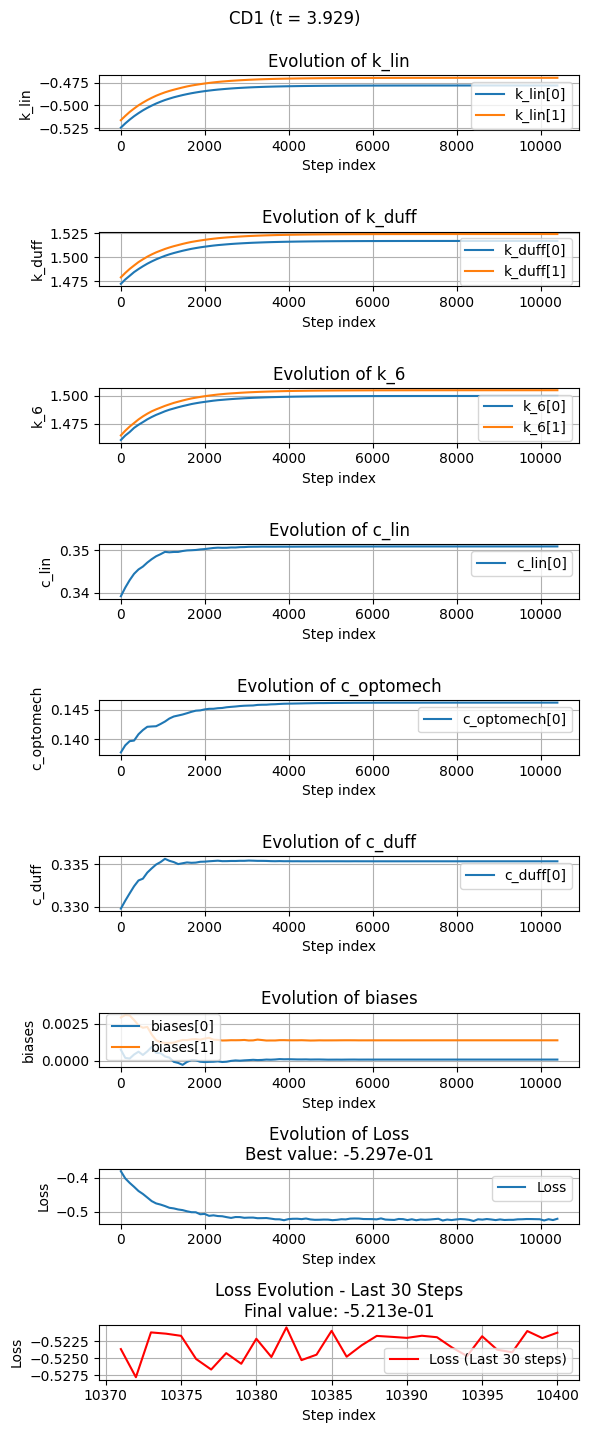

t_idx: 12, t_curr: 4.285714285714285
Epoch 0 - Loss: -0.5200 - Best Loss: -0.5200 (Epoch 0)
Epoch 100 - Loss: -0.5290 - Best Loss: -0.5319 (Epoch 93)
Epoch 200 - Loss: -0.5377 - Best Loss: -0.5405 (Epoch 193)
Epoch 300 - Loss: -0.5474 - Best Loss: -0.5507 (Epoch 286)
Epoch 400 - Loss: -0.5555 - Best Loss: -0.5570 (Epoch 397)
Epoch 500 - Loss: -0.5627 - Best Loss: -0.5670 (Epoch 494)
Epoch 600 - Loss: -0.5699 - Best Loss: -0.5711 (Epoch 580)
Epoch 700 - Loss: -0.5742 - Best Loss: -0.5769 (Epoch 684)
Epoch 800 - Loss: -0.5797 - Best Loss: -0.5828 (Epoch 796)
Epoch 900 - Loss: -0.5834 - Best Loss: -0.5856 (Epoch 894)
Epoch 1000 - Loss: -0.5842 - Best Loss: -0.5889 (Epoch 997)
Epoch 1100 - Loss: -0.5884 - Best Loss: -0.5908 (Epoch 1047)
Epoch 1200 - Loss: -0.5919 - Best Loss: -0.5948 (Epoch 1183)
Epoch 1300 - Loss: -0.5920 - Best Loss: -0.5962 (Epoch 1296)
Epoch 1400 - Loss: -0.5926 - Best Loss: -0.5971 (Epoch 1398)
Epoch 1500 - Loss: -0.5939 - Best Loss: -0.5992 (Epoch 1479)
Epoch 1600 - 

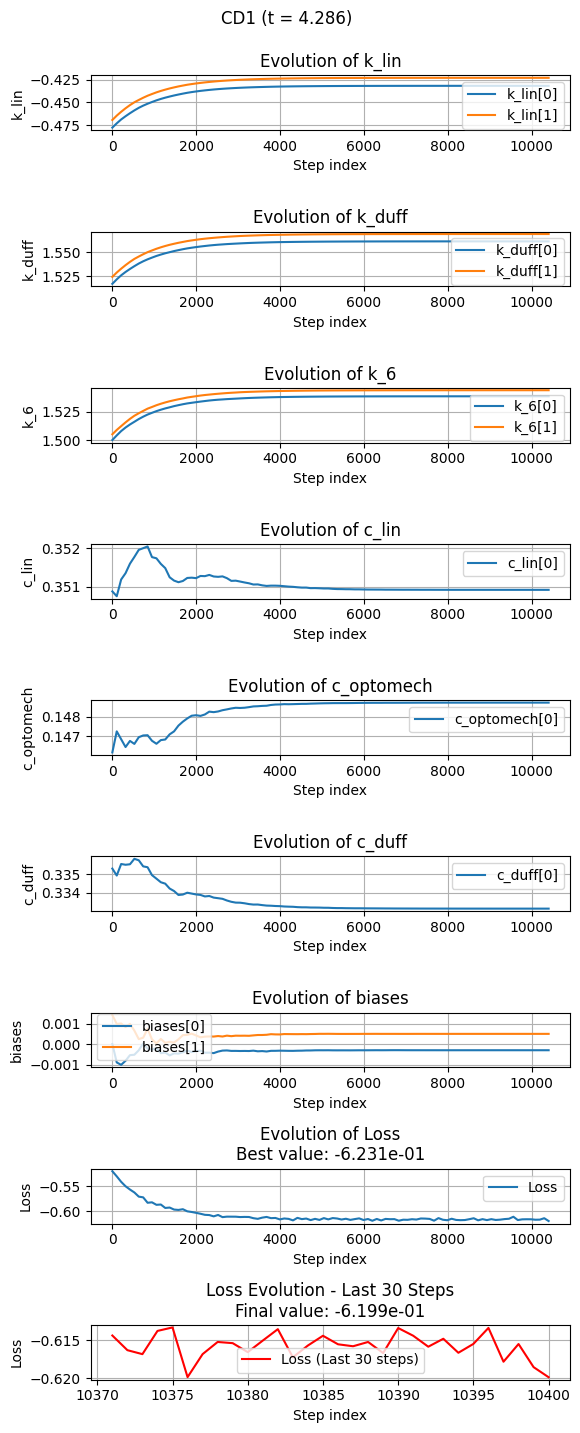

t_idx: 13, t_curr: 4.642857142857142
Epoch 0 - Loss: -0.6159 - Best Loss: -0.6159 (Epoch 0)
Epoch 100 - Loss: -0.6236 - Best Loss: -0.6250 (Epoch 98)
Epoch 200 - Loss: -0.6262 - Best Loss: -0.6321 (Epoch 196)
Epoch 300 - Loss: -0.6318 - Best Loss: -0.6355 (Epoch 256)
Epoch 400 - Loss: -0.6388 - Best Loss: -0.6413 (Epoch 391)
Epoch 500 - Loss: -0.6458 - Best Loss: -0.6475 (Epoch 497)
Epoch 600 - Loss: -0.6509 - Best Loss: -0.6526 (Epoch 586)
Epoch 700 - Loss: -0.6518 - Best Loss: -0.6539 (Epoch 688)
Epoch 800 - Loss: -0.6533 - Best Loss: -0.6573 (Epoch 784)
Epoch 900 - Loss: -0.6572 - Best Loss: -0.6596 (Epoch 838)
Epoch 1000 - Loss: -0.6607 - Best Loss: -0.6613 (Epoch 931)
Epoch 1100 - Loss: -0.6584 - Best Loss: -0.6641 (Epoch 1078)
Epoch 1200 - Loss: -0.6632 - Best Loss: -0.6660 (Epoch 1182)
Epoch 1300 - Loss: -0.6648 - Best Loss: -0.6666 (Epoch 1290)
Epoch 1400 - Loss: -0.6667 - Best Loss: -0.6687 (Epoch 1341)
Epoch 1500 - Loss: -0.6661 - Best Loss: -0.6706 (Epoch 1478)
Epoch 1600 - 

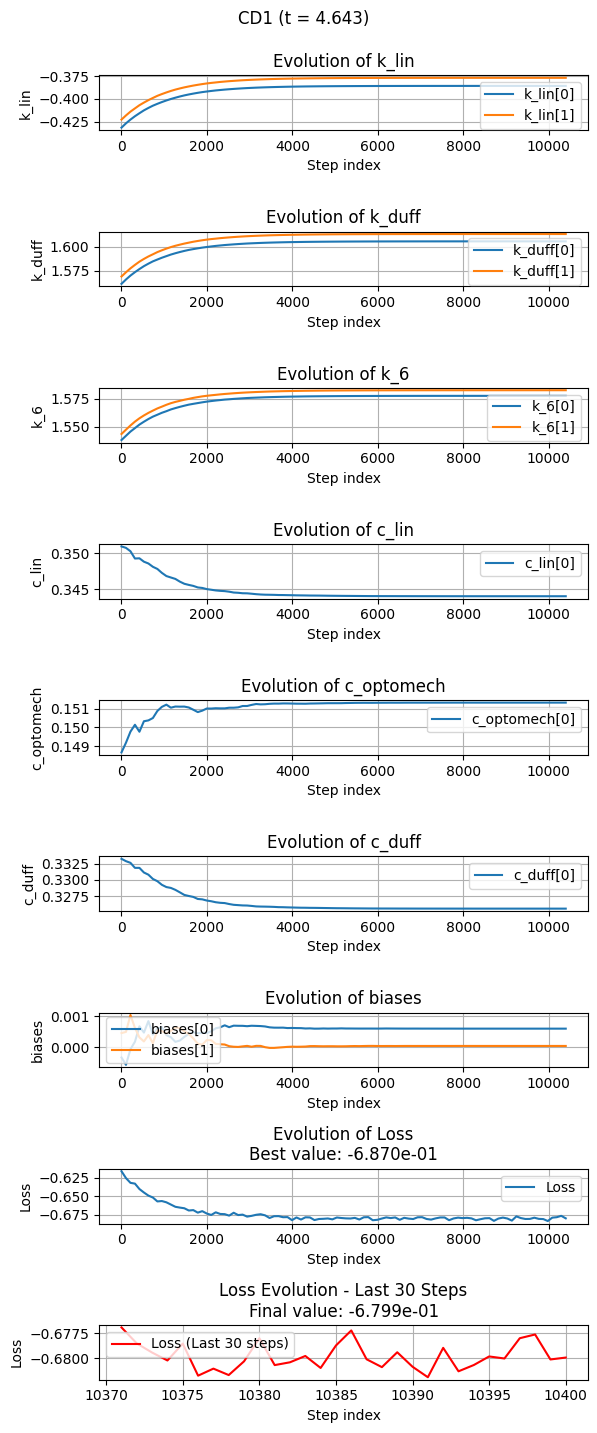

t_idx: 14, t_curr: 5.0
Epoch 0 - Loss: -0.6800 - Best Loss: -0.6800 (Epoch 0)
Epoch 100 - Loss: -0.6845 - Best Loss: -0.6873 (Epoch 99)
Epoch 200 - Loss: -0.6921 - Best Loss: -0.6957 (Epoch 198)
Epoch 300 - Loss: -0.6951 - Best Loss: -0.7013 (Epoch 299)
Epoch 400 - Loss: -0.7013 - Best Loss: -0.7043 (Epoch 362)
Epoch 500 - Loss: -0.7067 - Best Loss: -0.7079 (Epoch 494)
Epoch 600 - Loss: -0.7079 - Best Loss: -0.7099 (Epoch 578)
Epoch 700 - Loss: -0.7133 - Best Loss: -0.7150 (Epoch 688)
Epoch 800 - Loss: -0.7153 - Best Loss: -0.7183 (Epoch 785)
Epoch 900 - Loss: -0.7188 - Best Loss: -0.7209 (Epoch 850)
Epoch 1000 - Loss: -0.7246 - Best Loss: -0.7246 (Epoch 1000)
Epoch 1100 - Loss: -0.7248 - Best Loss: -0.7261 (Epoch 1092)
Epoch 1200 - Loss: -0.7238 - Best Loss: -0.7275 (Epoch 1168)
Epoch 1300 - Loss: -0.7215 - Best Loss: -0.7277 (Epoch 1296)
Epoch 1400 - Loss: -0.7261 - Best Loss: -0.7288 (Epoch 1327)
Epoch 1500 - Loss: -0.7226 - Best Loss: -0.7292 (Epoch 1448)
Epoch 1600 - Loss: -0.7279

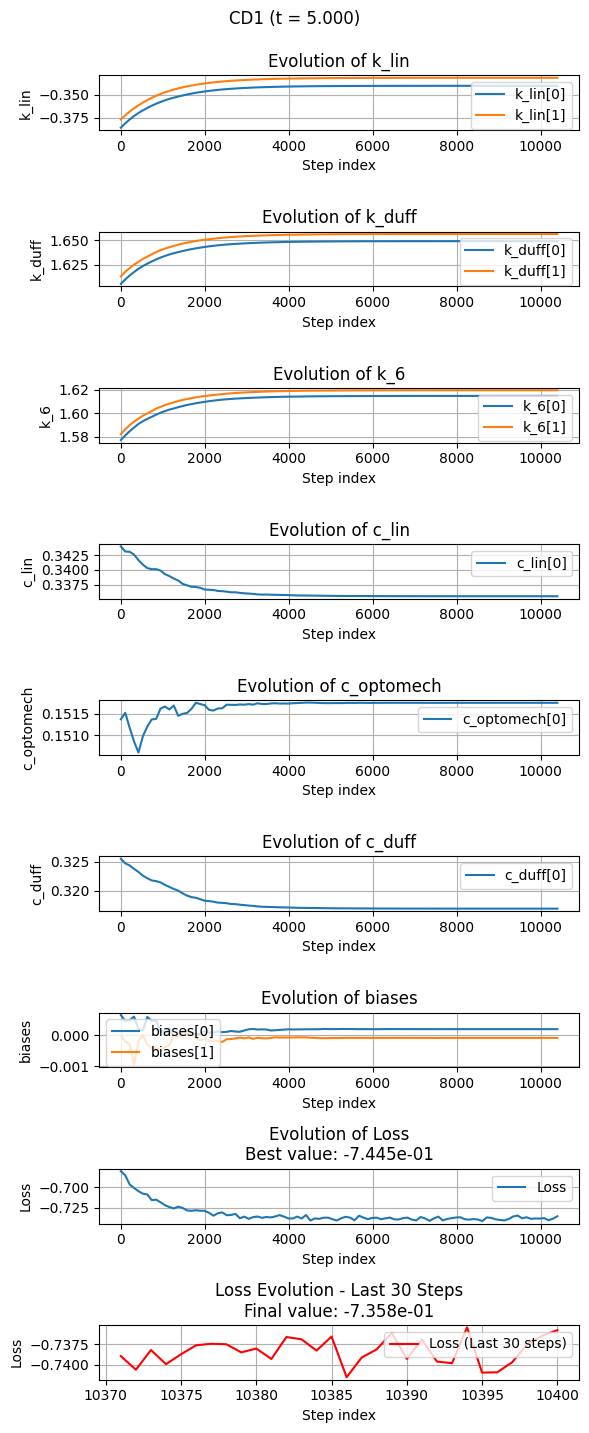

Optimization complete; saved parameters to ../out/problems/2026_01_16/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling_Temp_0.005/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/training_method_CD1_CD1_dt_1e-05_CD1_num_noise_samples_3000_exp_time_pts_False_t_forward_5.0_n_timesteps_15_sigma_forward_1.0_lr_5e-05_epochs_100000_batch_2048_window_500_tol_0.0001_patience_100


In [11]:
params_history_path = f"{output_dir}/params_history.npy"
# if os.path.exists(params_history_path):
#     # Load existing parameters
#     print('Loading existing parameters from', params_history_path)
#     params_history_all_t = jnp.load(params_history_path)
# else:
    # print('No existing parameters found, running optimization')    

# Setup optimization parameters
mask = jnp.ones(params_flattened_initial.shape[0])

# Plotting parameters
plot_steps = True  # Flag to control whether to plot during optimization
plot_slice = 1     # Plot every nth step

params_history_all_t = []
current_params = params_flattened_initial

# Loop over time points
for t_idx, t_curr in enumerate(forward_time_pts):
    print(f"t_idx: {t_idx}, t_curr: {t_curr}")
    optimization_key, optimization_subkey = jr.split(optimization_key)
    
    if t_idx == 0:
        samples_0 = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_target, key=optimization_key)
        plot_forward_marginals(samples_0, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=save_fig, fontsize=16, plot_show=True)
    
    sampler = lambda key: sample_forward_process(
            t_curr, n_samples = batch_size, D=Temp, sigma_final=sigma_forward, samples0=samples_target, key=key, beta= 1
        )
    
    # Perform optimization starting from previous best parameters
    params_history, loss_history, current_params, best_loss, best_epoch = run_optimization(
        loss_fn_per_batch=loss_fn_per_batch,
        params_initial=current_params,
        sampler=sampler,
        mask=mask,
        gradient_fn_per_batch=gradient_fn_per_batch,
        key=optimization_subkey,
        learning_rate=learning_rate,
        n_epochs=n_epochs,
        maximize=maximize,
        window_size=window_size,
        tolerance=tolerance,
        patience=patience,
        constraint_indices=constraint_indices
    )
    
    params_history_all_t.append(current_params)
    
    if plot_steps:
        if t_idx % plot_slice == 0:
            # Plot optimization progress
            plot_parameter_evolution(
                params_history=params_history,
                loss_history=loss_history,
                best_params=current_params,
                best_loss=best_loss,
                best_idx=best_epoch,
                time = t_curr,
                time_index = t_idx,
                unflatten=unflatten,
                N_osc=N_osc,
                # slicing=10,
                title=f"{training_method} (t = {t_curr:.3f})",
                maximize=maximize,
                labels_on=True,
                save_fig=save_fig,
                path=output_dir,
                param_names=params_names,
                plot_show=True
            )
        
# Convert params_history_all_t to array for easier analysis
params_history_all_t = jnp.array(params_history_all_t)
jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)

print('Optimization complete; saved parameters to', output_dir)

### Smoothen and interpolate parameter evolution

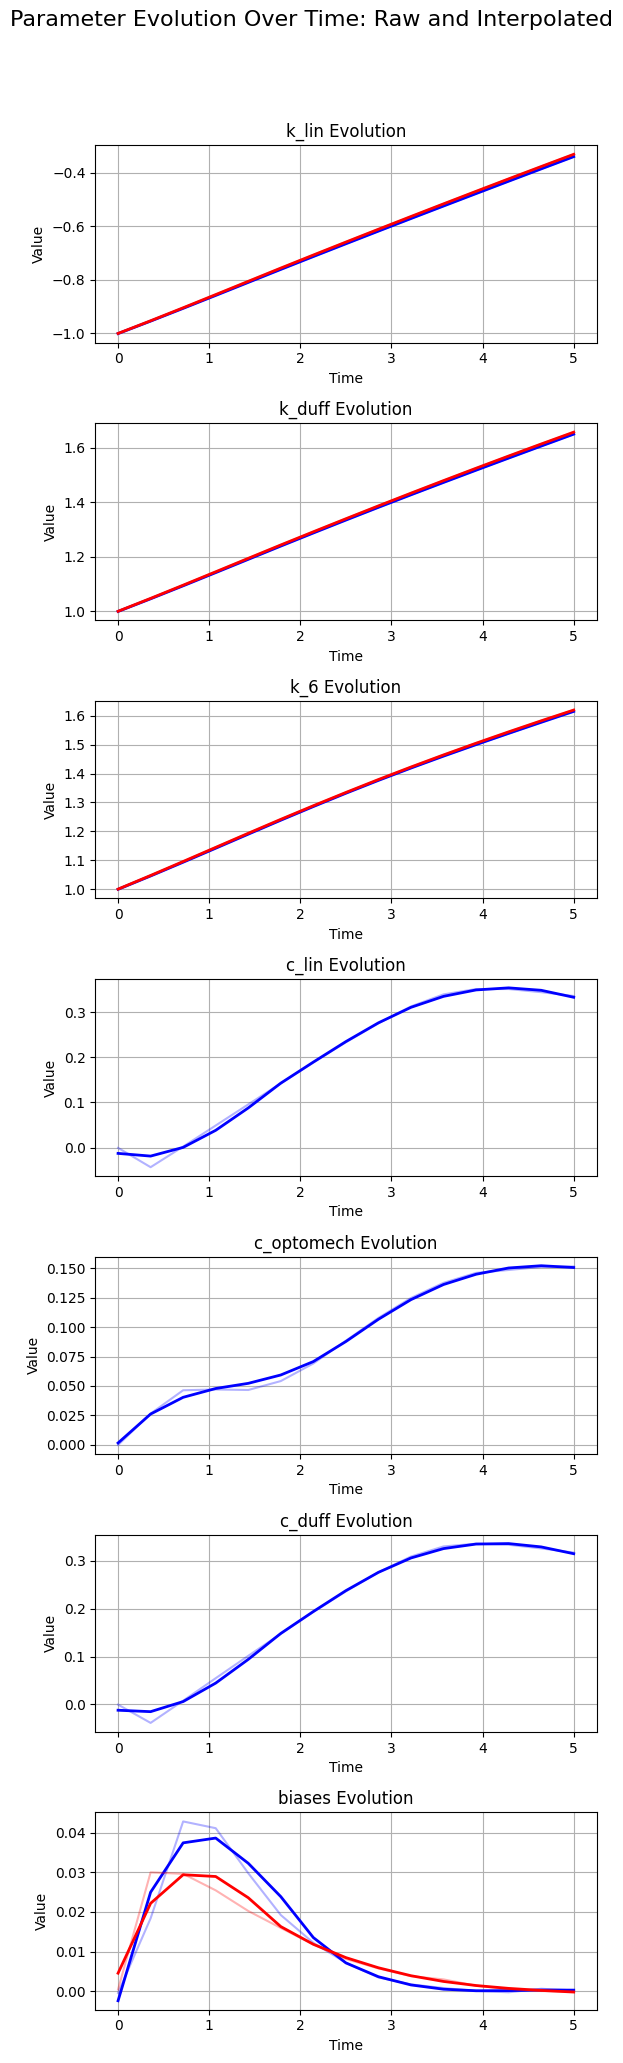

In [12]:
use_smoothed_params = False
smoothed_params = smooth_parameters(params_history_all_t, window_lengths=[10] * params_history_all_t.shape[1], poly_orders=[3] * params_history_all_t.shape[1])

# Get interpolator functions
params_interpolator_smoothed = interpolate_parameters(smoothed_params, forward_time_pts)
params_interpolator_non_smoothed = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0], forward_time_pts[-1], 200)
interpolated_params_smoothed = params_interpolator_smoothed(time_eval)
interpolated_params_non_smoothed = params_interpolator_non_smoothed(time_eval)

plot_parameter_as_fn_of_time(params_names, forward_time_pts, forward_time_pts, params_history_all_t, params_interpolator_smoothed, unflatten, N_osc, save_fig=True, path=plot_folder, log_scale=False,plot_show=True)

if use_smoothed_params:
    params_interpolator = params_interpolator_smoothed
else:
    params_interpolator = params_interpolator_non_smoothed

### Run reverse SDE:

In [13]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:N_osc].set(1.)
if Temp == 0.0:
    params_interpolator_reverse_plus_linear = lambda t: params_interpolator(t_forward - t) - 1 / sigma_forward**2 * forward_params
elif training_method == "CD1" or training_method == "SM_local":
    params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1 / sigma_forward**2 * forward_params
else: 
    params_interpolator_reverse_plus_linear = lambda t: 2*Temp*params_interpolator(t_forward - t) - 1 / sigma_forward**2 * forward_params


# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True, Temp=Temp)

t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.00000001
atol = 1e-2
rtol = 1e-3

n_trajectories = 2000

# Generate multiple initial states
reverse_sde_key, subkey_initial = jr.split(reverse_sde_key)
initial_states = sample_forward_process(t_forward, n_trajectories, sigma_final=sigma_forward, D=Temp, samples0=samples_target, key=subkey_initial)

# Generate a key for each initial condition
keys_brownian = jr.split(reverse_sde_key, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn,
        diffusion_fn,
        init_state,
        key_b,
        t0,
        t1,
        ts.shape[0],
        dt0,
        rtol=rtol,
        atol=atol
    ),
    in_axes=(0, 0)
)

# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys
final_states = all_trajectories[:, -1, :]

/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

### Run equillibirum SDE

In [14]:
t1 = n_trajectories*t_forward*0.00001
sde_samples_direct_path = f"{output_dir}/sde_samples_direct_simT_{t1}.npy"
if os.path.exists(sde_samples_direct_path):
    # Load existing parameters
    print('Loading existing equilibrium trajectory', sde_samples_direct_path)
    sde_samples_direct = jnp.load(sde_samples_direct_path)
else:
    print('No existing equilibrium trajectory found, running optimization')   
    drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(0), N_osc, Temp=Temp, time_dependent_parms=False)
    t0 = 0.0
    ts = jnp.linspace(t0, t1, n_trajectories)
    dt0 = ts[1] - ts[0]
    initial_state = jnp.array([-.0,0.])

    reverse_sde_key, subkey_direct = jr.split(reverse_sde_key)
    solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,subkey_direct, t0, t1, ts.shape[0], dt0,atol=atol,rtol=rtol)
    sde_samples_direct = solution_direct.ys
    jnp.save(f"{output_dir}/sde_samples_direct.npy", sde_samples_direct)


No existing equilibrium trajectory found, running optimization


/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

## Plot samples

    Reverse Trajectory total prob ≈ 1.000000
  Equilibrium Sampling total prob ≈ 1.000000


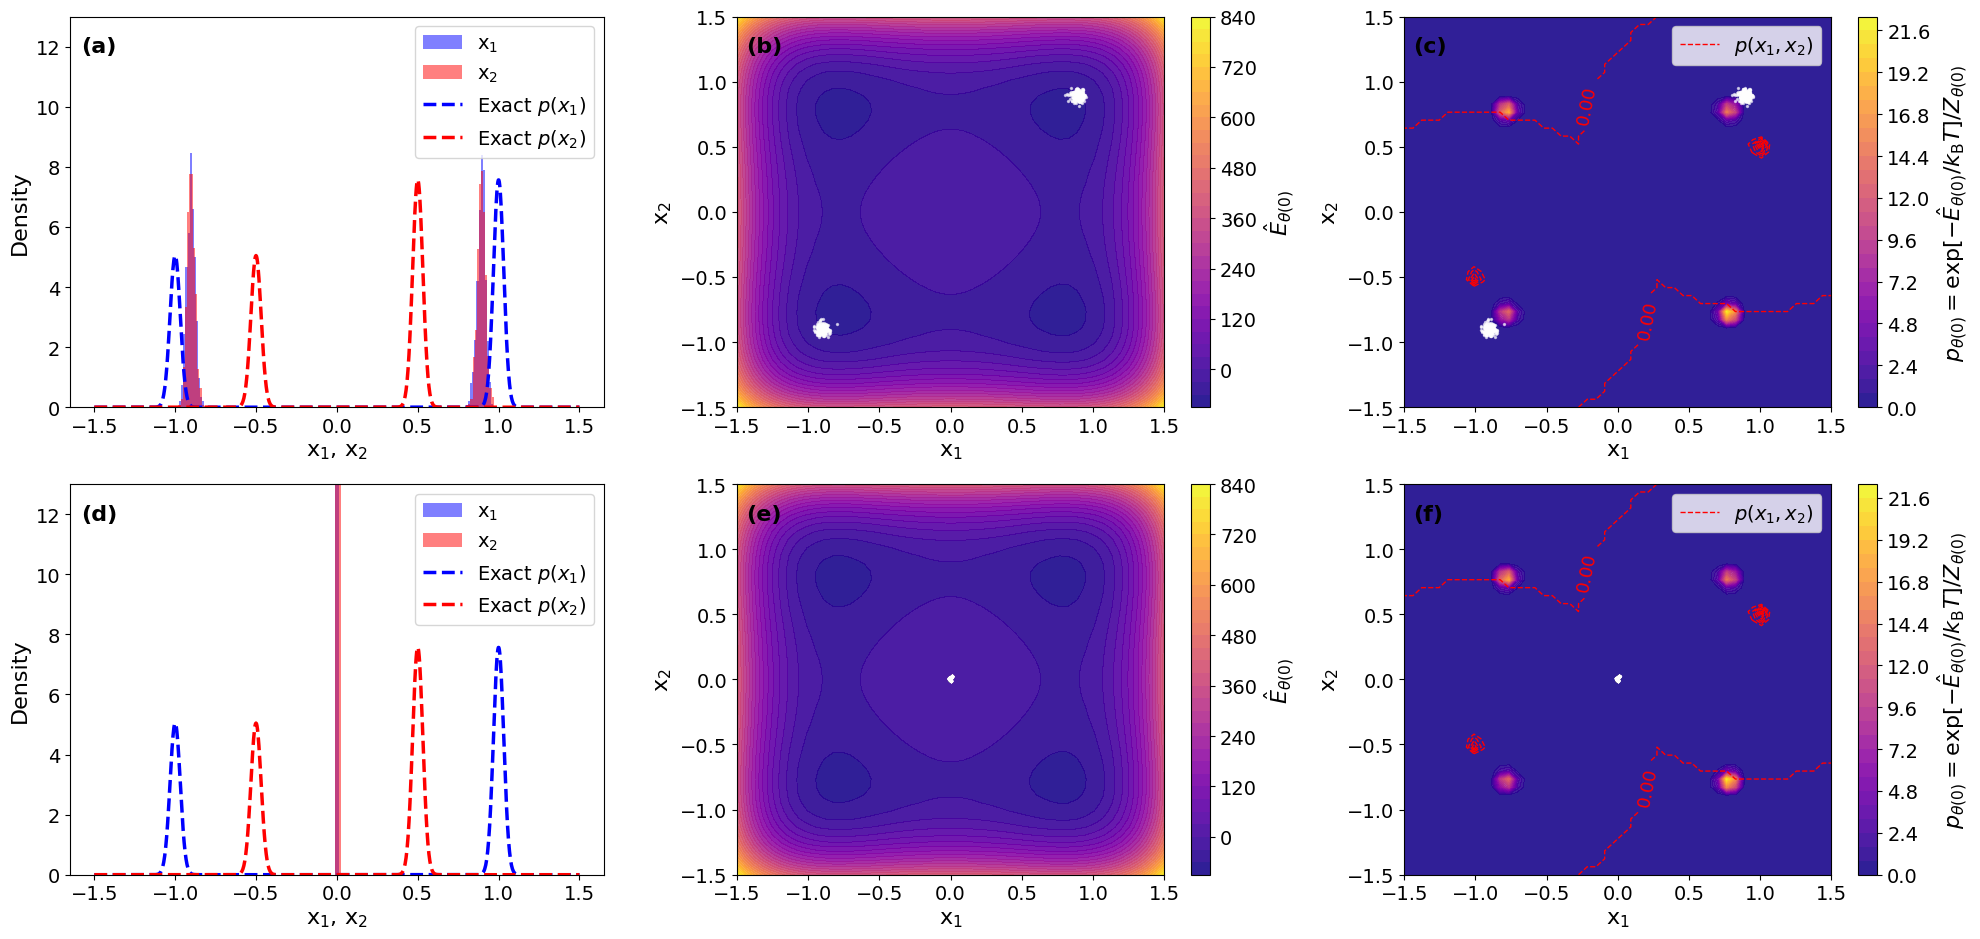

In [15]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# high-contrast violet→red
viored = LinearSegmentedColormap.from_list("viored", ["violet", "red"])

def plot_prl_comparison_with_iso_label(
    energy_fn,
    params_reverse,
    params_equil,
    reverse_samples,
    sde_samples_direct,
    weights, means, covs,       # GMM params
    *,                           # everything below here must be named
    x1_range=(-1.5, 1.5),
    x2_range=(-1.5, 1.5),
    n_points=200,
    num_bins=100,
    sample_stride=10,
    figsize=(7, 4),
    fontsize=10,
    label_fontsize=14,           # increased default label fontsize
    iso_levels=5,                # number of iso–contour levels
):
    # 1) Grid
    x1 = jnp.linspace(x1_range[0], x1_range[1], n_points)
    x2 = jnp.linspace(x2_range[0], x2_range[1], n_points)
    X1, X2 = jnp.meshgrid(x1, x2)
    dx, dy = x1[1] - x1[0], x2[1] - x2[0]

    # 2) Exact marginals for histograms
    x_lin = jnp.linspace(x1_range[0], x1_range[1], 1000)
    marginal_x1 = sum(
        w * jnp.exp(-0.5*((x_lin - m[0])**2)/C[0,0]) / jnp.sqrt(2*jnp.pi*C[0,0])
        for w,m,C in zip(weights, means, covs)
    )
    marginal_x2 = sum(
        w * jnp.exp(-0.5*((x_lin - m[1])**2)/C[1,1]) / jnp.sqrt(2*jnp.pi*C[1,1])
        for w,m,C in zip(weights, means, covs)
    )

    # 3) True 2D GMM density on grid
    true_prob = jnp.zeros_like(X1)
    for w, m, C in zip(weights, means, covs):
        diff = jnp.stack([X1 - m[0], X2 - m[1]], axis=-1)
        invC = jnp.linalg.inv(C)
        exponent = jnp.einsum('...i,ij,...j->...', diff, invC, diff)
        norm = jnp.sqrt((2*jnp.pi)**2 * jnp.linalg.det(C))
        true_prob += w * jnp.exp(-0.5 * exponent) / norm

    # 4) Compute E & model P for both methods
    E_list, P_list = [], []
    for params in (params_reverse, params_equil):
        E = jnp.zeros_like(X1)
        for i in range(n_points):
            for j in range(n_points):
                x = jnp.array([X1[i,j], X2[i,j]])
                E = E.at[i,j].set(energy_fn(x, params))
        P = jnp.exp(-E)
        P /= (jnp.sum(P) * dx * dy)
        E_list.append(E)
        P_list.append(P)

    # 5) Figure setup
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    labels = ['(a)','(b)','(c)','(d)','(e)','(f)']
    for ax, lab in zip(axes.flatten(), labels):
        ax.text(0.02, 0.95, lab,
                transform=ax.transAxes,
                fontsize=label_fontsize,
                fontweight='bold',
                va='top', ha='left')

    row_titles = ['Reverse Trajectory', 'Equilibrium Sampling']

    # 6) Plot rows
    for row, (title, samples) in enumerate(zip(row_titles,
                                              (reverse_samples, sde_samples_direct))):
        # — combined marginals
        ax = axes[row,0]
        ax.hist(samples[:,0], bins=num_bins, density=True,
                alpha=0.5, color='blue', label='x$_1$')
        ax.hist(samples[:,1], bins=num_bins, density=True,
                alpha=0.5, color='red',  label='x$_2$')
        ax.plot(x_lin, marginal_x1, '--b', lw=2.5, label='Exact $p(x_1)$')
        ax.plot(x_lin, marginal_x2, '--r', lw=2.5, label='Exact $p(x_2)$')
        ax.set_ylim(0, 13)
        ax.set_xlabel('x$_1$, x$_2$', fontsize=fontsize)
        ax.set_ylabel('Density', fontsize=fontsize)
        ax.legend(fontsize=fontsize-2, loc='upper right')
        ax.tick_params(labelsize=fontsize-2)

        # — energy map
        ax = axes[row,1]
        cf = ax.contourf(X1, X2, E_list[row], levels=30,
                         cmap='plasma', alpha=0.9)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\hat{E}_{\theta(0)}$', fontsize=label_fontsize)
        cbar.ax.tick_params(labelsize=label_fontsize-2)
        ax.scatter(samples[::sample_stride,0],
                   samples[::sample_stride,1],
                   c='white', s=2, alpha=0.6)
        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

        # — probability map + iso contours + legend entry
        ax = axes[row,2]
        cf = ax.contourf(X1, X2, P_list[row], levels=30,
                         cmap='plasma', alpha=0.9)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(
            r'$p_{\theta(0)} = \exp[-\hat{E}_{\theta(0)}/k_\mathrm{B}T]/Z_{\theta(0)}$',
            fontsize=label_fontsize
        )
        cbar.ax.tick_params(labelsize=label_fontsize-2)
        ax.scatter(samples[::sample_stride,0],
                   samples[::sample_stride,1],
                   c='white', s=2, alpha=0.6)
        iso = ax.contour(X1, X2, true_prob,
                         levels=iso_levels,
                         colors='red',
                         linestyles='--',
                         linewidths=1)
        ax.clabel(iso, fmt='%.2f', fontsize=fontsize-3)
        iso_proxy = Line2D(
            [0],[0],
            color='red',
            linestyle='--',
            linewidth=1,
            label=r'$p(x_1,x_2)$'
        )
        ax.legend(handles=[iso_proxy], fontsize=fontsize-2, loc='upper right')

        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

        # sanity check
        tot = jnp.sum(P_list[row]) * dx * dy
        print(f"{title:>22} total prob ≈ {tot:.6f}")

    fig.tight_layout(rect=[0,0,1,0.95])
    plt.savefig(f"{plot_folder}/fig_2D_mixture_comparison_Temp_{Temp}_num_traj_{n_trajectories}.png", dpi=300, bbox_inches='tight')
    plt.show()
    


# Example call:
plot_prl_comparison_with_iso_label(
    energy_fn,
    params_interpolator(0)/Temp,
    params_interpolator(0)/Temp,
    final_states,
    sde_samples_direct,
    weights, means, covs,          # GMM params
    n_points=50,
    num_bins=150,
    sample_stride=5,
    x1_range=(-1.5,1.5),
    x2_range=(-1.5,1.5),
    figsize=(20,10),
    fontsize=16,
    label_fontsize=16,
    iso_levels=7,
)


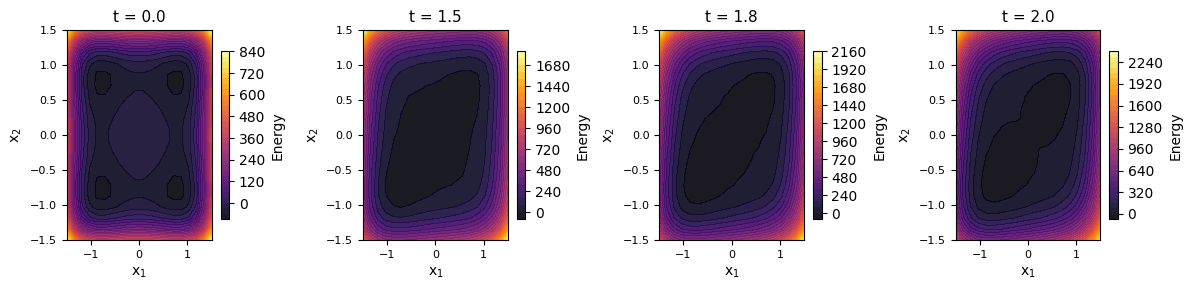

In [16]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# high‐contrast violet→red
viored = LinearSegmentedColormap.from_list("viored", ["violet", "red"])

def plot_energy_timepoints(
    energy_fn,
    params_interpolator,
    Temp,
    time_points=(0.0, 0.5, 1.0, 1.5),
    x1_range=(-1.5, 1.5),
    x2_range=(-1.5, 1.5),
    n_points=200,
    figsize=(12, 3),
    fontsize=10,
):
    """
    Plot energy landscapes at multiple time points side by side.

    Args:
        energy_fn:    fn(x, params) → scalar energy
        params_interpolator:  fn(t) → raw params
        Temp:         temperature scalar (divide params by Temp)
        time_points:  iterable of t values
        x1_range:     (min, max) for x₁
        x2_range:     (min, max) for x₂
        n_points:     grid resolution per axis
        figsize:      overall figure size (width, height)
        fontsize:     base font size for labels & titles
    """
    # build grid
    x1 = jnp.linspace(x1_range[0], x1_range[1], n_points)
    x2 = jnp.linspace(x2_range[0], x2_range[1], n_points)
    X1, X2 = jnp.meshgrid(x1, x2)

    fig, axes = plt.subplots(1, len(time_points), figsize=figsize, squeeze=False)
    axes = axes[0]

    for ax, t in zip(axes, time_points):
        # compute energy on grid
        params = params_interpolator(t) / Temp
        E = jnp.zeros_like(X1)
        for i in range(n_points):
            for j in range(n_points):
                x = jnp.array([X1[i, j], X2[i, j]])
                E = E.at[i, j].set(energy_fn(x, params))

        # plot
        cf = ax.contourf(X1, X2, E, levels=30, cmap='inferno', alpha=0.9)
        plt.colorbar(cf, ax=ax, label='Energy', shrink=0.8)
        ax.set_title(f"t = {t}", fontsize=fontsize+1)
        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

    fig.tight_layout()
    plt.show()


# USAGE EXAMPLE
plot_energy_timepoints(
    energy_fn,
    params_interpolator,
    Temp,
    time_points=(0.0, 1.5, 1.8, 2.0),
    x1_range=(-1.5, 1.5),
    x2_range=(-1.5, 1.5),
    n_points=20,
    figsize=(12,3),
    fontsize=10,
)


In [17]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# Print-friendly color schemes with high contrast
# Option 1: Grayscale with high contrast (best for B&W printing)
grayscale_cmap = LinearSegmentedColormap.from_list("grayscale_contrast", 
                                                   ["white", "lightgray", "gray", "darkgray", "black"])

# Option 2: Blue-white-red diverging (good contrast, colorblind friendly)
bwr_cmap = LinearSegmentedColormap.from_list("blue_white_red", 
                                             ["darkblue", "blue", "lightblue", "white", 
                                              "lightcoral", "red", "darkred"])

# Option 3: Viridis-like but with higher contrast
viridis_contrast = LinearSegmentedColormap.from_list("viridis_contrast",
                                                     ["#440154", "#31688e", "#35b779", "#fde725"])

# Option 4: Custom high-contrast scheme (purple to yellow)
purple_yellow = LinearSegmentedColormap.from_list("purple_yellow",
                                                  ["#2d1b69", "#5d2a8a", "#8e44ad", "#c39bd3", 
                                                   "#f7dc6f", "#f4d03f", "#f1c40f"])

def plot_prl_comparison_print_friendly(
    energy_fn,
    params_reverse,
    params_equil,
    reverse_samples,
    sde_samples_direct,
    weights, means, covs,       # GMM params
    *,                           # everything below here must be named
    x1_range=(-1.5, 1.5),
    x2_range=(-1.5, 1.5),
    n_points=200,
    num_bins=50,
    sample_stride=10,
    figsize=(7, 4),
    fontsize=10,
    label_fontsize=14,
    iso_levels=5,
    colormap='grayscale',        # NEW: colormap option
    contour_linewidth=2.0,       # NEW: thicker contour lines
    scatter_size=3,              # NEW: larger scatter points
    scatter_alpha=0.8,           # NEW: higher alpha for visibility
):
    """
    Print-friendly version with improved color schemes and visibility.
    
    colormap options:
    - 'grayscale': High-contrast grayscale (best for B&W printing)
    - 'bwr': Blue-white-red diverging
    - 'viridis_contrast': High-contrast viridis-like
    - 'purple_yellow': Purple to yellow high contrast
    - 'plasma': Original plasma (for comparison)
    """
    
    # Select colormap
    cmap_dict = {
        'grayscale': grayscale_cmap,
        'bwr': bwr_cmap,
        'viridis_contrast': viridis_contrast,
        'purple_yellow': purple_yellow,
        'plasma': 'plasma'
    }
    selected_cmap = cmap_dict.get(colormap, grayscale_cmap)
    
    # 1) Grid
    x1 = jnp.linspace(x1_range[0], x1_range[1], n_points)
    x2 = jnp.linspace(x2_range[0], x2_range[1], n_points)
    X1, X2 = jnp.meshgrid(x1, x2)
    dx, dy = x1[1] - x1[0], x2[1] - x2[0]

    # 2) Exact marginals for histograms
    x_lin = jnp.linspace(x1_range[0], x1_range[1], 1000)
    marginal_x1 = sum(
        w * jnp.exp(-0.5*((x_lin - m[0])**2)/C[0,0]) / jnp.sqrt(2*jnp.pi*C[0,0])
        for w,m,C in zip(weights, means, covs)
    )
    marginal_x2 = sum(
        w * jnp.exp(-0.5*((x_lin - m[1])**2)/C[1,1]) / jnp.sqrt(2*jnp.pi*C[1,1])
        for w,m,C in zip(weights, means, covs)
    )

    # 3) True 2D GMM density on grid
    true_prob = jnp.zeros_like(X1)
    for w, m, C in zip(weights, means, covs):
        diff = jnp.stack([X1 - m[0], X2 - m[1]], axis=-1)
        invC = jnp.linalg.inv(C)
        exponent = jnp.einsum('...i,ij,...j->...', diff, invC, diff)
        norm = jnp.sqrt((2*jnp.pi)**2 * jnp.linalg.det(C))
        true_prob += w * jnp.exp(-0.5 * exponent) / norm

    # 4) Compute E & model P for both methods
    E_list, P_list = [], []
    for params in (params_reverse, params_equil):
        E = jnp.zeros_like(X1)
        for i in range(n_points):
            for j in range(n_points):
                x = jnp.array([X1[i,j], X2[i,j]])
                E = E.at[i,j].set(energy_fn(x, params))
        P = jnp.exp(-E)
        P /= (jnp.sum(P) * dx * dy)
        E_list.append(E)
        P_list.append(P)

    # 5) Figure setup with improved styling
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    labels = ['(a)','(b)','(c)','(d)','(e)','(f)']
    for ax, lab in zip(axes.flatten(), labels):
        ax.text(0.02, 0.95, lab,
                transform=ax.transAxes,
                fontsize=label_fontsize,
                fontweight='bold',
                va='top', ha='left',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    row_titles = ['Reverse Trajectory', 'Equilibrium Sampling']

    # 6) Plot rows with improved visibility
    for row, (title, samples) in enumerate(zip(row_titles,
                                              (reverse_samples, sde_samples_direct))):
        # — combined marginals with thicker lines
        ax = axes[row,0]
        ax.hist(samples[:,0], bins=num_bins, density=True,
                alpha=0.6, color='blue', label='x$_1$', edgecolor='darkblue', linewidth=0.5)
        ax.hist(samples[:,1], bins=num_bins, density=True,
                alpha=0.6, color='red',  label='x$_2$', edgecolor='darkred', linewidth=0.5)
        ax.plot(x_lin, marginal_x1, '--', color='darkblue', lw=3, label='Exact $p(x_1)$')
        ax.plot(x_lin, marginal_x2, '--', color='darkred', lw=3, label='Exact $p(x_2)$')
        ax.set_ylim(0, 13)
        ax.set_xlabel('x$_1$, x$_2$', fontsize=fontsize)
        ax.set_ylabel('Density', fontsize=fontsize)
        ax.legend(fontsize=fontsize-2, loc='upper right')
        ax.tick_params(labelsize=fontsize-2)
        ax.grid(True, alpha=0.3)

        # — energy map with improved colormap
        ax = axes[row,1]
        cf = ax.contourf(X1, X2, E_list[row], levels=30,
                         cmap=selected_cmap, alpha=0.95)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\hat{E}_{\theta(0)}$', fontsize=label_fontsize)
        cbar.ax.tick_params(labelsize=label_fontsize-2)
        
        # Improved scatter points
        scatter_color = 'white' if colormap == 'grayscale' else 'black'
        ax.scatter(samples[::sample_stride,0],
                   samples[::sample_stride,1],
                   c=scatter_color, s=scatter_size, alpha=scatter_alpha,
                   edgecolors='black' if scatter_color == 'white' else 'white',
                   linewidths=0.5)
        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

        # — probability map with improved contours
        ax = axes[row,2]
        cf = ax.contourf(X1, X2, P_list[row], levels=30,
                         cmap=selected_cmap, alpha=0.95)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(
            r'$p_{\theta(0)} = \exp[-\hat{E}_{\theta(0)}/k_\mathrm{B}T]/Z_{\theta(0)}$',
            fontsize=label_fontsize
        )
        cbar.ax.tick_params(labelsize=label_fontsize-2)
        
        # Improved scatter points
        ax.scatter(samples[::sample_stride,0],
                   samples[::sample_stride,1],
                   c=scatter_color, s=scatter_size, alpha=scatter_alpha,
                   edgecolors='black' if scatter_color == 'white' else 'white',
                   linewidths=0.5)
        
        # Thicker, more visible contour lines
        iso = ax.contour(X1, X2, true_prob,
                         levels=iso_levels,
                         colors='yellow',
                         linestyles='--',
                         linewidths=contour_linewidth)
        ax.clabel(iso, fmt='%.2f', fontsize=fontsize-2, inline=True)
        
        iso_proxy = Line2D(
            [0],[0],
            color='yellow',
            linestyle='--',
            linewidth=contour_linewidth,
            label=r'$p(x_1,x_2)$'
        )
        ax.legend(handles=[iso_proxy], fontsize=fontsize-2, loc='upper right')

        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

        # sanity check
        tot = jnp.sum(P_list[row]) * dx * dy
        print(f"{title:>22} total prob ≈ {tot:.6f}")

    # fig.suptitle(f'Print-Friendly Version (colormap: {colormap})', fontsize=label_fontsize+2)
    fig.tight_layout(rect=[0,0,1,0.95])
    
    # Save with colormap info in filename
    plt.savefig(f"{plot_folder}/fig_2D_mixture_comparison_print_friendly_{colormap}_Temp_{Temp}_num_traj_{n_trajectories}_atol_{atol}_rtol_{rtol}.png", 
                dpi=300, bbox_inches='tight')
    plt.show()

print("Available colormap options:")
print("- 'grayscale': High-contrast grayscale (best for B&W printing)")
print("- 'bwr': Blue-white-red diverging") 
print("- 'viridis_contrast': High-contrast viridis-like")
print("- 'purple_yellow': Purple to yellow high contrast")
print("- 'plasma': Original plasma (for comparison)")


Available colormap options:
- 'grayscale': High-contrast grayscale (best for B&W printing)
- 'bwr': Blue-white-red diverging
- 'viridis_contrast': High-contrast viridis-like
- 'purple_yellow': Purple to yellow high contrast
- 'plasma': Original plasma (for comparison)



=== BLUE-WHITE-RED VERSION (Colorblind friendly) ===
    Reverse Trajectory total prob ≈ 1.000000
  Equilibrium Sampling total prob ≈ 1.000000


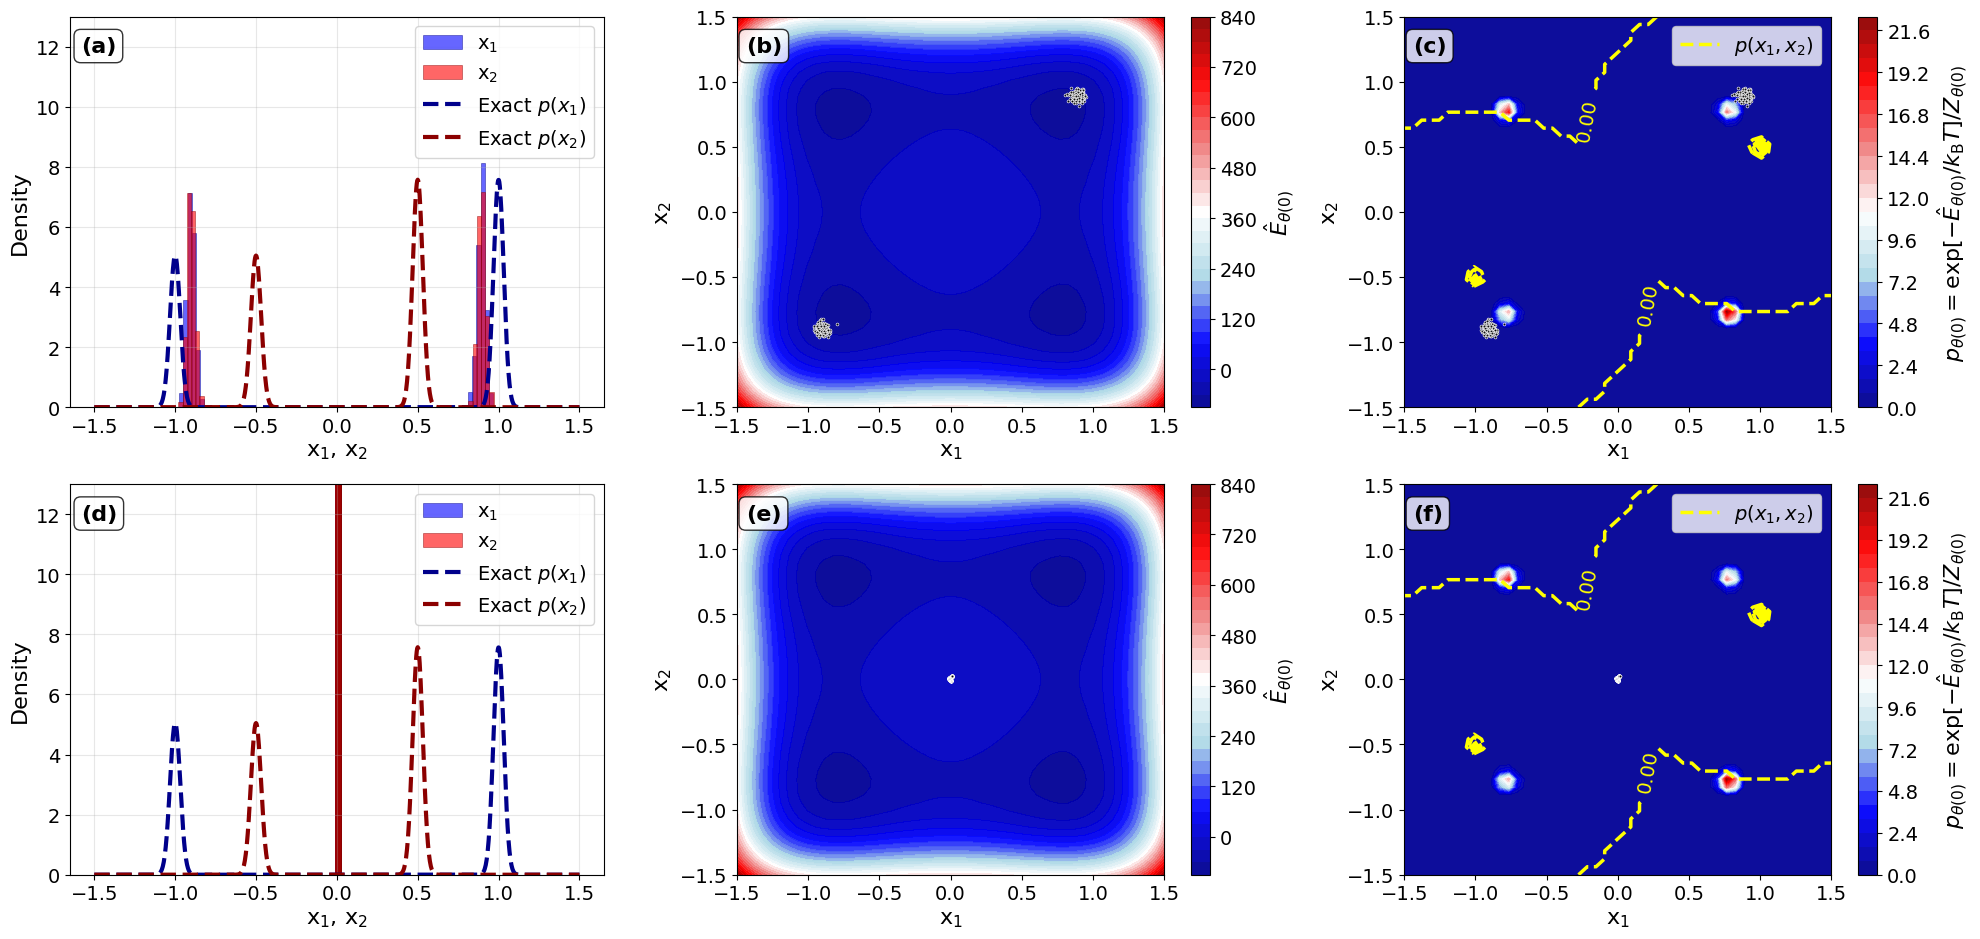

In [18]:
# Example usage with different colormap options
# Test the print-friendly version with different color schemes

# # Grayscale version (best for B&W printing)
# print("=== GRAYSCALE VERSION (Best for B&W printing) ===")
# plot_prl_comparison_print_friendly(
#     energy_fn,
#     params_interpolator(0)/Temp,
#     params_interpolator(0)/Temp,
#     final_states,
#     sde_samples_direct,
#     weights, means, covs,
#     n_points=50,
#     num_bins=150,
#     sample_stride=5,
#     x1_range=(-1.5,1.5),
#     x2_range=(-1.5,1.5),
#     figsize=(20,10),
#     fontsize=16,
#     label_fontsize=16,
#     iso_levels=7,
#     colormap='grayscale',
#     contour_linewidth=2.5,
#     scatter_size=4,
#     scatter_alpha=0.9
# )

# Blue-white-red diverging version (colorblind friendly)
print("\n=== BLUE-WHITE-RED VERSION (Colorblind friendly) ===")
plot_prl_comparison_print_friendly(
    energy_fn,
    params_interpolator(0)/Temp,
    params_interpolator(0)/Temp,
    final_states,
    sde_samples_direct,
    weights, means, covs,
    n_points=50,
    num_bins=75,
    sample_stride=5,
    x1_range=(-1.5,1.5),
    x2_range=(-1.5,1.5),
    figsize=(20,10),
    fontsize=16,
    label_fontsize=16,
    iso_levels=7,
    colormap='bwr',
    contour_linewidth=2.5,
    scatter_size=4,
    scatter_alpha=0.9
)

# # High-contrast viridis version
# print("\n=== HIGH-CONTRAST VIRIDIS VERSION ===")
# plot_prl_comparison_print_friendly(
#     energy_fn,
#     params_interpolator(0)/Temp,
#     params_interpolator(0)/Temp,
#     final_states,
#     sde_samples_direct,
#     weights, means, covs,
#     n_points=50,
#     num_bins=150,
#     sample_stride=5,
#     x1_range=(-1.5,1.5),
#     x2_range=(-1.5,1.5),
#     figsize=(20,10),
#     fontsize=16,
#     label_fontsize=16,
#     iso_levels=7,
#     colormap='viridis_contrast',
#     contour_linewidth=2.5,
#     scatter_size=4,
#     scatter_alpha=0.9
# )
